# Универсальный калькулятор экспериментов для банковских моделей и коммуникаций

Ноутбук помогает спроектировать и проанализировать не только обычный A/B‑тест, но и более сложные банковские эксперименты:

- churn, дефолт, мошенничество и другие редкие события;
- продажи, отклик, активация продукта и использование сервиса;
- сравнение нескольких каналов: контроль, SMS, push, email, звонок;
- uplift‑модели и персонализированный выбор клиентов для воздействия;
- multi-treatment / next-best-action: выбор лучшего канала или оффера для каждого клиента;
- ограничение capacity: например, колл‑центр может обработать только часть клиентов;
- непрерывные метрики: маржа, доход, остатки, LTV, стоимость риска;
- время до churn/default, повторные события и competing risks;
- кластерные эксперименты по менеджерам, отделениям или компаниям.

## Как читать ноутбук

Каждый раздел построен в трёх слоях:

1. **Простыми словами** — какой бизнес-вопрос решает метод.
2. **Когда применять / когда не применять** — практическая подсказка.
3. **Техническая часть** — функции, допущения и код.

Пользователь без глубокой статистической подготовки может читать первые два слоя и запускать готовые примеры. Технические комментарии предназначены для аналитиков, Data Scientist и валидаторов.

> Ключевое правило: калькулятор проверяет не «модель сама по себе», а политику принятия решения — кто получает воздействие, какое воздействие получает, при каком пороге и с какими ограничениями.

> Важно: нельзя выбирать метод, primary metric, correction или правило остановки после просмотра результата. Всё это фиксируется до старта эксперимента.

## Небольшой словарь терминов

| Термин | Простое объяснение |
|---|---|
| **Baseline** | Текущая частота или среднее значение метрики без нового воздействия. |
| **MDE** | Минимальный эффект, ради которого проектируется эксперимент. Это не обещание, что именно такой эффект будет доказан. |
| **Alpha / Type I error** | Допустимый риск ошибочно объявить успех, когда реального эффекта нет. |
| **Power / мощность** | Вероятность обнаружить заранее заданный реальный эффект. |
| **Exact test / точный тест** | Тест, который не опирается на нормальную аппроксимацию и лучше подходит для единичных событий. |
| **Interim analysis** | Заранее запланированный промежуточный просмотр результата. |
| **Futility** | Ранняя остановка, когда шанс получить убедительный итог уже слишком мал. |
| **Prior / posterior** | Знание до эксперимента / обновлённое знание после учёта данных. |
| **ESS prior** | Условная «сила» prior в эквиваленте наблюдений. |
| **Hazard** | Интенсивность наступления события среди клиентов, у которых оно ещё не произошло. |
| **RMST** | Среднее время без события до выбранного горизонта. |
| **Estimand** | Точный объект оценки: например, снижение churn за 6 месяцев или прибавка дней до churn. |
| **Cluster / кластер** | Группа зависимых наблюдений: клиенты одного менеджера, отделения или компании. |
| **Competing risk** | Другое событие, которое препятствует наступлению интересующего события. |
| **Recurrent event** | Событие, которое может повторяться у одного клиента несколько раз. |
| **Multi-arm test** | Эксперимент с контролем и несколькими вариантами воздействия. |
| **Multiplicity** | Рост вероятности случайного успеха, когда проверяется много гипотез. |
| **Contrast** | Заранее заданное сравнение: SMS против контроля, звонок против push и т. п. |
| **Uplift / CATE** | Изменение результата именно из-за воздействия для клиента или сегмента. |
| **Uplift policy** | Правило, определяющее, кому воздействовать на основе прогнозируемого эффекта. |
| **Qini / AUUC** | Метрики качества ранжирования клиентов по ожидаемому индивидуальному эффекту. |
| **Propensity** | Вероятность получить конкретное воздействие в данных эксперимента. |
| **IPW** | Оценка, исправляющая неравные вероятности назначения через веса 1/propensity. |
| **Doubly robust / DR** | Оценка, объединяющая propensity и модель результата; остаётся корректной, если верна хотя бы одна из этих частей при стандартных допущениях. |
| **Policy value** | Ожидаемый результат или прибыль при использовании заданной политики. |
| **Capacity** | Ограничение ресурса: число звонков, бюджет скидок, объём ручной обработки. |
| **Factorial design** | Дизайн, который одновременно оценивает эффекты канала, текста, времени и их взаимодействий. |
| **Interaction** | Ситуация, когда эффект одного фактора зависит от другого: например, текст работает в push, но не в SMS. |

В коде сохранены общепринятые английские названия, чтобы их было проще сопоставлять с документацией и статьями.

## Маршрут выбора метода

| Бизнес-вопрос | Рекомендуемый раздел |
|---|---|
| Сколько клиентов и месяцев нужно в обычном A/B‑тесте? | 2 |
| Событий очень мало, Z‑тест вызывает сомнения | 3 |
| Хотим смотреть результат несколько раз и раньше остановиться | 4–5 |
| Хотим Bayesian‑вероятности и исторический prior | 6 |
| Есть риск‑скор или хорошие признаки до эксперимента | 7 |
| Нельзя отдавать 50% клиентов в контроль | 8 |
| Важен момент churn/default, а не только факт | 9–12 |
| Сравниваем несколько каналов с общим контролем | 14 |
| Сравниваем каналы несколько раз по ходу эксперимента | 15 |
| Проверяем качество uplift‑модели | 16 |
| Оцениваем новую персонализированную политику или NBA | 17 |
| Выбираем канал с учётом стоимости и capacity | 17 |
| Проверяем канал × текст × время отправки | 18 |
| Нужен итоговый план действий | 13 и 19 |

### Короткое правило для выбора уровня сложности

- **Один treatment против контроля:** начинайте с разделов 2–8.
- **Несколько каналов:** используйте multi-arm, а не несколько независимых A/B‑тестов.
- **Uplift-модель:** сначала проверяйте ранжирование и policy value, затем запускайте A/B‑тест итоговой политики.
- **Multi-treatment / NBA:** обязательны propensity, overlap и оценка стоимости действий.
- **Много комбинаций факторов:** используйте factorial design вместо десятков несвязанных групп.
- **Редкие события:** exact или simulation-based расчёт важнее красивой аналитической формулы.

## Карта применения для банковских задач

| Задача | Что является treatment | Основной результат | Рекомендуемые разделы | Важное ограничение |
|---|---|---|---|---|
| Churn / удержание | звонок, скидка, новая политика отбора | churn, RMST, прибыль удержания | 2–12 | тестировать политику воздействия, а не только скор |
| Продажи / propensity | коммуникация или оффер | отклик, выдача, маржа | 2–8, 14 | учитывать стоимость и каннибализацию |
| Uplift-модель | таргетинг по прогнозному uplift | incremental response/profit | 16–17 | нужны рандомизированные данные и независимая оценка |
| Next-best-action | выбор одного из нескольких действий | policy value | 14, 17 | обязательны propensity и overlap по каждому действию |
| Каналы коммуникации | SMS, push, email, звонок | конверсия, прибыль, жалобы | 14–15 | нужна поправка на множественные сравнения |
| Канал × текст × время | комбинация факторов | конверсия/маржа | 18 | заранее определить важные interactions |
| Кредитный риск / default | реструктуризация, лимит, стратегия | default, loss, time-to-default | 3, 9–12 | редкость событий, competing risks и моральный риск |
| Fraud / AML | правило проверки или приоритизация | потери, найденные кейсы, workload | 3–8, 14 | стоимость false positive и ограничение расследований |
| Pricing | ставка или тариф | доход, take-up, риск | 14, 18 | эффект на спрос и риск нужно оценивать совместно |
| LTV / остатки | коммуникация или сервисное изменение | непрерывная метрика | 7, 14, 17 | тяжёлые хвосты: нужны robust/bootstrapped интервалы |
| Менеджеры/отделения | политика на уровне сотрудника | клиентская метрика | 8, 11 | рандомизация и анализ должны учитывать кластеры |

> Если модель только прогнозирует риск, но не меняет действие, A/B‑тест модели невозможен. Сначала нужно определить, какое решение меняется из-за её прогноза.

## 0. Импорт библиотек и настройки

In [1]:
# При необходимости установите недостающие библиотеки:
# %pip install numpy pandas scipy statsmodels matplotlib ipywidgets scikit-learn

from __future__ import annotations

import math
import warnings
from dataclasses import dataclass, asdict
from functools import lru_cache
from typing import Iterable, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import brentq
from scipy.special import betaln, expit, logit, logsumexp

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import statsmodels.api as sm

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
RNG = np.random.default_rng(42)

from statsmodels.stats.multitest import multipletests
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from scipy.optimize import milp, LinearConstraint, Bounds
from itertools import product, combinations


## 1. Основные параметры

Ниже находится основной блок, который пользователь обычно меняет первым.

### Пример по умолчанию

- churn в контроле: 0,5%;
- ожидаемый churn в treatment: 0,4%;
- относительное снижение: 20%;
- доступно 10 000 клиентов в месяц;
- мощность: 80%;
- alpha: 5%;
- распределение: 50/50.

In [2]:
BASE_RATE = 0.005
RELATIVE_REDUCTION = 0.20
CLIENTS_PER_MONTH = 10_000

ALPHA = 0.05
POWER = 0.80
SIDED = 'one-sided'       # 'one-sided' или 'two-sided'
TREATMENT_SHARE = 0.50
MAX_MONTHS = 12

TREATMENT_RATE = BASE_RATE * (1 - RELATIVE_REDUCTION)

print(f'Контроль: {BASE_RATE:.3%}')
print(f'Treatment: {TREATMENT_RATE:.3%}')
print(f'Абсолютное изменение: {TREATMENT_RATE - BASE_RATE:.3%}')
print(f'Относительное снижение: {RELATIVE_REDUCTION:.1%}')

Контроль: 0.500%
Treatment: 0.400%
Абсолютное изменение: -0.100%
Относительное снижение: 20.0%


## 2. Базовый fixed-horizon A/B‑тест

### Простыми словами

Мы заранее определяем размер выборки, набираем её полностью и один раз принимаем решение.

### Когда применять

- бинарная primary metric;
- независимые группы;
- решение принимается один раз;
- ожидаемых событий достаточно для нормальной аппроксимации.

### Когда не применять без дополнительной проверки

- событий единицы;
- результат просматривается каждую неделю;
- рандомизация идёт по менеджерам или отделениям;
- есть сильное недополучение treatment;
- эффект меняется во времени.

In [3]:
@dataclass
class FixedDesignResult:
    p_control: float
    p_treatment: float
    alpha: float
    power: float
    sided: str
    treatment_share: float
    n_control: int
    n_treatment: int
    n_total: int
    months: float
    expected_events_control: float
    expected_events_treatment: float
    expected_events_total: float


def _alternative_from_sided(sided: str) -> str:
    if sided == 'one-sided':
        return 'larger'
    if sided == 'two-sided':
        return 'two-sided'
    raise ValueError("sided должен быть 'one-sided' или 'two-sided'")


def fixed_binary_design(
    p_control: float,
    p_treatment: float,
    alpha: float = 0.05,
    power: float = 0.80,
    treatment_share: float = 0.50,
    sided: str = 'one-sided',
    clients_per_month: float | None = None,
) -> FixedDesignResult:
    """Классический расчёт выборки для сравнения двух долей."""
    if not (0 < p_control < 1 and 0 < p_treatment < 1):
        raise ValueError('Вероятности должны быть между 0 и 1.')
    if p_control == p_treatment:
        raise ValueError('Эффект равен нулю: требуемая выборка бесконечна.')
    if not (0 < treatment_share < 1):
        raise ValueError('treatment_share должен быть между 0 и 1.')

    ratio = treatment_share / (1 - treatment_share)
    effect_size = abs(proportion_effectsize(p_control, p_treatment))
    solver = NormalIndPower()
    n_control_float = solver.solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        ratio=ratio,
        alternative=_alternative_from_sided(sided),
    )
    n_control = math.ceil(n_control_float)
    n_treatment = math.ceil(n_control * ratio)
    n_total = n_control + n_treatment
    months = n_total / clients_per_month if clients_per_month else float('nan')

    e0 = n_control * p_control
    e1 = n_treatment * p_treatment
    return FixedDesignResult(
        p_control, p_treatment, alpha, power, sided, treatment_share,
        n_control, n_treatment, n_total, months, e0, e1, e0 + e1
    )


baseline = fixed_binary_design(
    BASE_RATE, TREATMENT_RATE, ALPHA, POWER,
    TREATMENT_SHARE, SIDED, CLIENTS_PER_MONTH
)
display(pd.DataFrame([asdict(baseline)]).T.rename(columns={0: 'Значение'}))

,Значение
p_control,0.0050
p_treatment,0.0040
alpha,0.0500
power,0.8000
sided,one-sided
treatment_share,0.5000
n_control,55222
n_treatment,55222
n_total,110444
months,11.0444


,Месяц,Контроль,Treatment,Ожидаемые события,Мощность
0,1,5000,5000,45.0000,0.1850
1,2,10000,10000,90.0000,0.2787
2,3,15000,15000,135.0000,0.3636
3,4,20000,20000,180.0000,0.4410
4,5,25000,25000,225.0000,0.5112
5,6,30000,30000,270.0000,0.5745
6,7,35000,35000,315.0000,0.6311
7,8,40000,40000,360.0000,0.6813
8,9,45000,45000,405.0000,0.7257
9,10,50000,50000,450.0000,0.7646


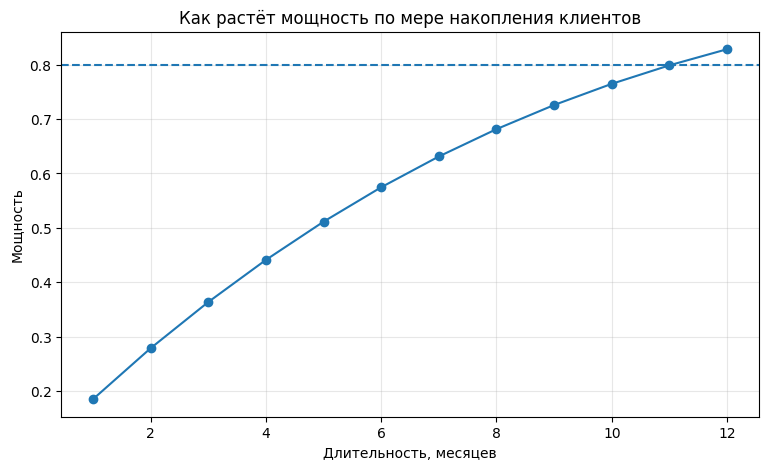

In [4]:
def binary_power_given_sample(
    p_control: float,
    p_treatment: float,
    n_control: int,
    n_treatment: int,
    alpha: float = 0.05,
    sided: str = 'one-sided',
) -> float:
    effect_size = abs(proportion_effectsize(p_control, p_treatment))
    return NormalIndPower().power(
        effect_size=effect_size,
        nobs1=n_control,
        alpha=alpha,
        ratio=n_treatment / n_control,
        alternative=_alternative_from_sided(sided),
    )


rows=[]
for month in range(1, MAX_MONTHS + 1):
    n_total = month * CLIENTS_PER_MONTH
    n_t = round(n_total * TREATMENT_SHARE)
    n_c = n_total - n_t
    rows.append({
        'Месяц': month,
        'Контроль': n_c,
        'Treatment': n_t,
        'Ожидаемые события': n_c*BASE_RATE + n_t*TREATMENT_RATE,
        'Мощность': binary_power_given_sample(
            BASE_RATE, TREATMENT_RATE, n_c, n_t, ALPHA, SIDED
        )
    })
power_curve = pd.DataFrame(rows)
display(power_curve)

plt.figure(figsize=(9, 5))
plt.plot(power_curve['Месяц'], power_curve['Мощность'], marker='o')
plt.axhline(POWER, linestyle='--')
plt.xlabel('Длительность, месяцев')
plt.ylabel('Мощность')
plt.title('Как растёт мощность по мере накопления клиентов')
plt.grid(alpha=0.3)
plt.show()

### Event-driven план: ориентируемся на число событий

При редком churn календарный месяц сам по себе мало что говорит. Полезнее запланировать interim-анализы после накопления определённой доли от требуемого числа событий.

Например:

- 33% информации — ранний контроль сильного эффекта;
- 67% — основной промежуточный анализ;
- 100% — максимальная выборка.

Если фактическая частота churn ниже ожидаемой, календарный срок автоматически увеличится, даже если число пришедших клиентов не изменилось.

In [5]:
def event_driven_plan(
    design: FixedDesignResult,
    clients_per_month: int,
    information_fractions=(0.33,0.67,1.0),
) -> pd.DataFrame:
    """
    Переводит долю статистической информации в ожидаемое число событий
    и ориентировочный календарный месяц.
    """
    monthly_events=(
        clients_per_month*(1-design.treatment_share)*design.p_control
        +clients_per_month*design.treatment_share*design.p_treatment
    )
    rows=[]
    for fraction in information_fractions:
        target_events=design.expected_events_total*fraction
        rows.append({
            'Доля информации':fraction,
            'Целевое число событий':math.ceil(target_events),
            'Ожидаемый месяц':target_events/monthly_events,
        })
    return pd.DataFrame(rows)


display(event_driven_plan(baseline,CLIENTS_PER_MONTH))

,Доля информации,Целевое число событий,Ожидаемый месяц
0,0.3300,165,3.6447
1,0.6700,333,7.3997
2,1.0000,497,11.0444


## 3. Редкие события и точные тесты

### Простыми словами

Z-тест заменяет дискретное биномиальное распределение гладкой нормальной кривой. При большом числе событий это удобно и точно. При единичных событиях замена становится грубой.

В этом разделе доступны:

- **Z-test** — быстрый базовый вариант;
- **Fisher exact** — строгий условный exact-тест, иногда консервативный;
- **Boschloo exact** — часто мощнее Fisher;
- **Barnard exact** — unconditional exact-тест, часто мощнее Fisher;
- **Exact binomial** — только для сравнения одной доли с фиксированным нормативом, а не как основной тест двух независимых групп.

### Практический выбор

- 20–30+ событий в каждой группе: Z-тест обычно допустим.
- 5–20 событий: показывайте Z и exact рядом.
- <5 событий: exact/симуляция должны быть основными.

Порог 5 — предупреждение, а не магическая граница. Лучше дополнительно проверить фактическую ошибку первого рода симуляцией.

In [6]:
def rare_event_diagnostics(
    n_control: int,
    n_treatment: int,
    p_control: float,
    p_treatment: float,
) -> pd.Series:
    e0 = n_control * p_control
    e1 = n_treatment * p_treatment
    min_e = min(e0, e1)

    if min_e < 5:
        recommendation = 'Использовать exact или полностью симуляционный анализ.'
        level = 'КРАСНЫЙ'
    elif min_e < 20:
        recommendation = 'Сравнить Z и exact; проверить Type I error симуляцией.'
        level = 'ЖЁЛТЫЙ'
    else:
        recommendation = 'Z-аппроксимация обычно приемлема; exact можно оставить как sensitivity check.'
        level = 'ЗЕЛЁНЫЙ'

    return pd.Series({
        'Ожидаемые события — контроль': e0,
        'Ожидаемые события — treatment': e1,
        'P(0 событий) — контроль': (1-p_control)**n_control,
        'P(0 событий) — treatment': (1-p_treatment)**n_treatment,
        'Уровень предупреждения': level,
        'Рекомендация': recommendation,
    })


display(rare_event_diagnostics(
    baseline.n_control, baseline.n_treatment, BASE_RATE, TREATMENT_RATE
))

Ожидаемые события — контроль                                              276.1100
Ожидаемые события — treatment                                             220.8880
P(0 событий) — контроль                                                     0.0000
P(0 событий) — treatment                                                    0.0000
Уровень предупреждения                                                     ЗЕЛЁНЫЙ
Рекомендация                     Z-аппроксимация обычно приемлема; exact можно ...
dtype: object

In [7]:
def two_group_pvalue(
    x_control: int,
    n_control: int,
    x_treatment: int,
    n_treatment: int,
    method: str = 'z',
    sided: str = 'one-sided',
) -> float:
    """
    Возвращает p-value для гипотезы, что treatment снижает частоту события.

    Таблица строится как:
        control   [events, non-events]
        treatment [events, non-events]

    Для one-sided альтернативы улучшение означает:
        p_control > p_treatment.
    """
    table = np.array([
        [x_control, n_control - x_control],
        [x_treatment, n_treatment - x_treatment],
    ])
    alternative = 'greater' if sided == 'one-sided' else 'two-sided'

    if method == 'z':
        p0 = x_control / n_control
        p1 = x_treatment / n_treatment
        pooled = (x_control + x_treatment) / (n_control + n_treatment)
        se = math.sqrt(max(
            pooled*(1-pooled)*(1/n_control + 1/n_treatment), 1e-15
        ))
        z = (p0 - p1) / se
        if sided == 'one-sided':
            return float(1 - stats.norm.cdf(z))
        return float(2 * (1 - stats.norm.cdf(abs(z))))

    if method == 'fisher':
        return float(stats.fisher_exact(table, alternative=alternative).pvalue)
    if method == 'boschloo':
        return float(stats.boschloo_exact(table, alternative=alternative).pvalue)
    if method == 'barnard':
        return float(stats.barnard_exact(table, alternative=alternative).pvalue)

    raise ValueError("method: 'z', 'fisher', 'boschloo' или 'barnard'")


def one_sample_exact_binomial(
    observed_events: int,
    n: int,
    benchmark_rate: float,
    alternative: str = 'less',
) -> float:
    """
    Exact binomial test для ОДНОЙ группы против фиксированного норматива.

    Пример: проверка, что дефолтность новой политики ниже утверждённого лимита 1%.
    Это не замена двухгрупповому A/B-тесту.
    """
    return float(stats.binomtest(
        observed_events, n=n, p=benchmark_rate, alternative=alternative
    ).pvalue)

In [8]:
def _cached_pvalue_factory(method, n_control, n_treatment, sided):
    cache = {}
    def get(x0, x1):
        key = (int(x0), int(x1))
        if key not in cache:
            cache[key] = two_group_pvalue(
                key[0], n_control, key[1], n_treatment, method, sided
            )
        return cache[key]
    return get


def simulate_binary_operating_characteristics(
    p_control: float,
    p_treatment: float,
    n_control: int,
    n_treatment: int,
    methods=('z', 'fisher', 'boschloo', 'barnard'),
    alpha: float = 0.05,
    sided: str = 'one-sided',
    simulations: int = 1_000,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Симуляционная проверка тестов.

    Если p_control == p_treatment, колонка rejection_rate оценивает Type I error.
    Если доли различаются, она оценивает мощность.

    Для финальной валидации увеличьте simulations до 20 000–100 000.
    В демонстрации число меньше, чтобы ноутбук выполнялся быстро.
    """
    rng = np.random.default_rng(seed)
    x0 = rng.binomial(n_control, p_control, simulations)
    x1 = rng.binomial(n_treatment, p_treatment, simulations)

    rows=[]
    for method in methods:
        get_p = _cached_pvalue_factory(method, n_control, n_treatment, sided)
        pvals = np.array([get_p(a, b) for a, b in zip(x0, x1)])
        rows.append({
            'method': method,
            'rejection_rate': np.mean(pvals <= alpha),
            'mean_pvalue': np.mean(pvals),
            'P(zero in any arm)': np.mean((x0 == 0) | (x1 == 0)),
            'simulations': simulations,
        })
    return pd.DataFrame(rows)


# Намеренно редкий VIP-пример, чтобы различия методов были заметнее.
VIP_N_C = 400
VIP_N_T = 400
VIP_P_C = 0.008
VIP_P_T = 0.004

print('Диагностика VIP-примера:')
display(rare_event_diagnostics(VIP_N_C, VIP_N_T, VIP_P_C, VIP_P_T))

print('Type I error при отсутствии эффекта:')
display(simulate_binary_operating_characteristics(
    VIP_P_C, VIP_P_C, VIP_N_C, VIP_N_T,
    simulations=250, seed=1
))

print('Мощность при заданном эффекте:')
display(simulate_binary_operating_characteristics(
    VIP_P_C, VIP_P_T, VIP_N_C, VIP_N_T,
    simulations=250, seed=2
))

Диагностика VIP-примера:


Ожидаемые события — контроль                                                3.2000
Ожидаемые события — treatment                                               1.6000
P(0 событий) — контроль                                                     0.0402
P(0 событий) — treatment                                                    0.2012
Уровень предупреждения                                                     КРАСНЫЙ
Рекомендация                     Использовать exact или полностью симуляционный...
dtype: object

Type I error при отсутствии эффекта:


,method,rejection_rate,mean_pvalue,P(zero in any arm),simulations
0,z,0.0640,0.4939,0.0840,250
1,fisher,0.0360,0.6080,0.0840,250
2,boschloo,0.0560,0.5599,0.0840,250
3,barnard,0.0120,0.7594,0.0840,250


Мощность при заданном эффекте:


,method,rejection_rate,mean_pvalue,P(zero in any arm),simulations
0,z,0.1520,0.2793,0.2320,250
1,fisher,0.0440,0.4154,0.2320,250
2,boschloo,0.1040,NaN,0.2320,250
3,barnard,0.0160,0.5149,0.2320,250


### Как читать таблицу

- В строке **Type I error** значение должно быть не выше alpha с учётом Monte Carlo-погрешности.
- В строке **мощность** большее значение означает более высокую вероятность обнаружить реальный эффект.
- Fisher может быть консервативным: меньше ложных срабатываний, но иногда меньше мощности.
- Boschloo и Barnard часто выигрывают по мощности, однако требуют больше вычислений.

Не выбирайте метод по тому, какой из них дал меньший p-value на уже увиденных данных. Метод фиксируется заранее.

## 4. Обычный group-sequential дизайн

### Простыми словами

Мы заранее выбираем несколько моментов просмотра результата. Для каждого момента действует более строгая граница, поэтому общий риск ложного успеха остаётся под контролем.

- **O’Brien–Fleming**: очень строгий ранний успех, небольшой штраф в финале.
- **Pocock**: проще остановиться раньше, но финальная граница строже.

Этот раздел лучше подходит, когда событий уже достаточно для Z-аппроксимации. Для единичных событий используйте exact-sequential раздел 5.

In [9]:
def _correlation_from_information_times(info_times: Sequence[float]) -> np.ndarray:
    t = np.asarray(info_times, dtype=float)
    k = len(t)
    corr = np.empty((k, k))
    for i in range(k):
        for j in range(k):
            corr[i, j] = math.sqrt(min(t[i], t[j]) / max(t[i], t[j]))
    return corr


def calibrate_group_sequential_boundaries(
    info_times=(0.33, 0.67, 1.0),
    alpha=0.05,
    family='obf',
    sided='one-sided',
    simulations=100_000,
    seed=123,
):
    info_times = np.asarray(info_times, dtype=float)
    corr = _correlation_from_information_times(info_times)
    rng = np.random.default_rng(seed)
    z_null = rng.multivariate_normal(np.zeros(len(info_times)), corr, size=simulations)

    def boundaries(c):
        if family.lower() == 'obf':
            return c / np.sqrt(info_times)
        if family.lower() == 'pocock':
            return np.repeat(c, len(info_times))
        raise ValueError("family должен быть 'obf' или 'pocock'")

    def crossing_probability(c):
        b = boundaries(c)
        if sided == 'one-sided':
            return np.mean((z_null >= b).any(axis=1))
        return np.mean((np.abs(z_null) >= b).any(axis=1))

    c_star = brentq(lambda c: crossing_probability(c) - alpha, 0.5, 6.0)
    b = boundaries(c_star)
    return pd.DataFrame({
        'look': np.arange(1, len(info_times)+1),
        'information_fraction': info_times,
        'z_boundary': b,
        'nominal_one_sided_p': 1-stats.norm.cdf(b),
    })


gs_boundaries = calibrate_group_sequential_boundaries(
    info_times=(0.33, 0.67, 1.0), alpha=ALPHA,
    family='obf', sided=SIDED, simulations=50_000
)
display(gs_boundaries)

,look,information_fraction,z_boundary,nominal_one_sided_p
0,1,0.3300,2.9743,0.0015
1,2,0.6700,2.0874,0.0184
2,3,1.0000,1.7086,0.0438


In [10]:
def expected_z_binary(p_control, p_treatment, n_control, n_treatment):
    pooled = (n_control*p_control + n_treatment*p_treatment)/(n_control+n_treatment)
    se = math.sqrt(pooled*(1-pooled)*(1/n_control + 1/n_treatment))
    return (p_control-p_treatment)/se


def simulate_group_sequential_design(
    p_control,
    p_treatment,
    n_control_max,
    n_treatment_max,
    boundaries_df,
    futility_cp_threshold=None,
    simulations=30_000,
    seed=321,
):
    info_times = boundaries_df['information_fraction'].to_numpy()
    bounds = boundaries_df['z_boundary'].to_numpy()
    corr = _correlation_from_information_times(info_times)
    theta_final = expected_z_binary(
        p_control, p_treatment, n_control_max, n_treatment_max
    )
    means = theta_final*np.sqrt(info_times)
    rng = np.random.default_rng(seed)
    z_paths = rng.multivariate_normal(means, corr, size=simulations)

    stopped = np.zeros(simulations, dtype=bool)
    success = np.zeros(simulations, dtype=bool)
    stop_fraction = np.ones(simulations)
    reason = np.array(['max_sample']*simulations, dtype=object)

    for j, (t, b) in enumerate(zip(info_times, bounds)):
        active = ~stopped
        efficacy = active & (z_paths[:, j] >= b)
        success[efficacy] = True
        stopped[efficacy] = True
        stop_fraction[efficacy] = t
        reason[efficacy] = 'efficacy'

        if futility_cp_threshold is not None and j < len(info_times)-1:
            active = ~stopped
            z_now = z_paths[:, j]
            final_boundary = bounds[-1]
            conditional_mean = np.sqrt(t)*z_now + theta_final*(1-t)
            conditional_sd = np.sqrt(1-t)
            cp = 1-stats.norm.cdf((final_boundary-conditional_mean)/conditional_sd)
            futility = active & (cp < futility_cp_threshold)
            stopped[futility] = True
            stop_fraction[futility] = t
            reason[futility] = 'futility'

    return {
        'success_probability': success.mean(),
        'expected_sample_fraction': stop_fraction.mean(),
        'expected_total_sample': round(stop_fraction.mean()*(n_control_max+n_treatment_max)),
        'expected_months': stop_fraction.mean()*(n_control_max+n_treatment_max)/CLIENTS_PER_MONTH,
        'stop_reason_distribution': pd.Series(reason).value_counts(normalize=True),
    }


display(pd.Series(simulate_group_sequential_design(
    BASE_RATE, TREATMENT_RATE,
    baseline.n_control, baseline.n_treatment,
    gs_boundaries, futility_cp_threshold=0.10
)))

success_probability                                                    0.7880
expected_sample_fraction                                               0.8115
expected_total_sample                                                   89628
expected_months                                                        8.9628
stop_reason_distribution    efficacy     0.7880
max_sample   0.1799
futili...
dtype: object

## 5. Exact-sequential дизайн для экстремально редких событий

### Простыми словами

Мы всё равно смотрим данные несколько раз, но на каждом просмотре используем exact-тест. Обычный порог `p < 0.05` применять нельзя: повторные просмотры увеличат число ложных побед.

Ниже порог p-value калибруется симуляцией под:

- конкретные размеры групп;
- конкретные моменты просмотра;
- выбранный exact-тест;
- конкретную нулевую частоту события.

### Ограничение

Это симуляционно откалиброванный дизайн. Для официального протокола число симуляций должно быть значительно больше демонстрационного, а калибровка — воспроизводимой и независимо проверенной.

In [11]:
def simulate_sequential_pvalue_paths(
    p_control: float,
    p_treatment: float,
    n_control_max: int,
    n_treatment_max: int,
    info_times=(0.33, 0.67, 1.0),
    method='fisher',
    sided='one-sided',
    simulations=2_000,
    seed=42,
):
    """Симулирует накопленные exact p-values на всех interim looks."""
    rng = np.random.default_rng(seed)
    info_times = np.asarray(info_times)
    ncs = np.maximum(1, np.round(n_control_max*info_times).astype(int))
    nts = np.maximum(1, np.round(n_treatment_max*info_times).astype(int))

    # События генерируются по приращениям, поэтому траектория реалистично накопительная.
    inc_nc = np.diff(np.r_[0, ncs])
    inc_nt = np.diff(np.r_[0, nts])
    inc_xc = rng.binomial(inc_nc, p_control, size=(simulations, len(info_times)))
    inc_xt = rng.binomial(inc_nt, p_treatment, size=(simulations, len(info_times)))
    cum_xc = np.cumsum(inc_xc, axis=1)
    cum_xt = np.cumsum(inc_xt, axis=1)

    p_paths = np.ones((simulations, len(info_times)))
    caches = [dict() for _ in info_times]
    for j, (nc, nt) in enumerate(zip(ncs, nts)):
        cache = caches[j]
        for i in range(simulations):
            key = (int(cum_xc[i, j]), int(cum_xt[i, j]))
            if key not in cache:
                cache[key] = two_group_pvalue(
                    key[0], int(nc), key[1], int(nt), method, sided
                )
            p_paths[i, j] = cache[key]
    return p_paths, ncs, nts


def calibrate_exact_sequential_boundary(
    null_rate: float,
    n_control_max: int,
    n_treatment_max: int,
    info_times=(0.33, 0.67, 1.0),
    method='fisher',
    alpha=0.05,
    sided='one-sided',
    simulations=3_000,
    seed=101,
):
    """
    Находит наибольший общий порог p-value, при котором симулированный
    общий Type I error не превышает alpha.

    Из-за дискретности exact p-values достигнутый alpha может быть ниже 5%.
    """
    p_paths, ncs, nts = simulate_sequential_pvalue_paths(
        null_rate, null_rate, n_control_max, n_treatment_max,
        info_times, method, sided, simulations, seed
    )
    min_p = p_paths.min(axis=1)
    candidates = np.unique(min_p)
    valid = [c for c in candidates if np.mean(min_p <= c) <= alpha]
    boundary = max(valid) if valid else 0.0
    achieved_alpha = np.mean(min_p <= boundary)
    return {
        'p_boundary': boundary,
        'achieved_type_I_error': achieved_alpha,
        'n_control_looks': ncs,
        'n_treatment_looks': nts,
        'calibration_simulations': simulations,
    }


def evaluate_exact_sequential_design(
    p_control,
    p_treatment,
    n_control_max,
    n_treatment_max,
    p_boundary,
    info_times=(0.33, 0.67, 1.0),
    method='fisher',
    sided='one-sided',
    simulations=2_000,
    seed=202,
):
    p_paths, ncs, nts = simulate_sequential_pvalue_paths(
        p_control, p_treatment, n_control_max, n_treatment_max,
        info_times, method, sided, simulations, seed
    )
    crossed = p_paths <= p_boundary
    any_cross = crossed.any(axis=1)
    first = np.argmax(crossed, axis=1)
    stop_fraction = np.ones(simulations)
    info_times = np.asarray(info_times)
    stop_fraction[any_cross] = info_times[first[any_cross]]
    return pd.Series({
        'success_probability': any_cross.mean(),
        'expected_sample_fraction': stop_fraction.mean(),
        'expected_total_sample': round(stop_fraction.mean()*(n_control_max+n_treatment_max)),
    })


# Демонстрация на маленьком VIP-дизайне.
exact_calibration = calibrate_exact_sequential_boundary(
    null_rate=VIP_P_C,
    n_control_max=VIP_N_C,
    n_treatment_max=VIP_N_T,
    info_times=(0.33, 0.67, 1.0),
    method='fisher',
    simulations=1_200,
)
display(pd.Series(exact_calibration))

print('Независимая проверка Type I error:')
display(evaluate_exact_sequential_design(
    VIP_P_C, VIP_P_C, VIP_N_C, VIP_N_T,
    exact_calibration['p_boundary'],
    simulations=800, seed=303
))

print('Оценка мощности:')
display(evaluate_exact_sequential_design(
    VIP_P_C, VIP_P_T, VIP_N_C, VIP_N_T,
    exact_calibration['p_boundary'],
    simulations=800, seed=404
))

p_boundary                          0.0618
achieved_type_I_error               0.0492
n_control_looks            [132, 268, 400]
n_treatment_looks          [132, 268, 400]
calibration_simulations               1200
dtype: object

Независимая проверка Type I error:


success_probability          0.0400
expected_sample_fraction     0.9871
expected_total_sample      790.0000
dtype: float64

Оценка мощности:


success_probability          0.1163
expected_sample_fraction     0.9706
expected_total_sample      776.0000
dtype: float64

### Как использовать exact-sequential безопасно

1. Зафиксировать null rate и сценарии чувствительности.
2. Зафиксировать размеры групп и моменты просмотра.
3. Выбрать exact-тест до старта.
4. Выполнить калибровку минимум на десятках тысяч симуляций.
5. Проверить Type I error на независимом seed.
6. Проверить мощность на нескольких реалистичных эффектах.
7. Сохранить код, seed и итоговые границы в протоколе.

Если null rate сильно меняется по сезонам, проверьте контроль alpha на диапазоне возможных baseline rates, а не только в одной точке.

## 6. Bayesian-анализ: priors, robust borrowing и sensitivity analysis

### Простыми словами

Bayesian-анализ объединяет:

- то, что было известно до эксперимента;
- то, что наблюдается сейчас.

Чем сильнее prior, тем заметнее исторические данные влияют на результат. Поэтому prior нельзя выбирать только потому, что он делает интервал уже.

### Ключевое различие

`Beta(5, 995)` имеет среднее 0,5%, но effective sample size около 1000. Для маленького эксперимента это уже информативный prior.

В калькулятор добавлены:

- prior через mean + ESS;
- discounted historical prior;
- prior predictive check;
- sensitivity analysis;
- robust mixture prior;
- logit-модель, отдельно описывающая baseline и treatment effect.

In [12]:
def beta_prior_from_mean_ess(mean: float, ess: float) -> tuple[float, float]:
    if not (0 < mean < 1):
        raise ValueError('mean должен быть между 0 и 1')
    if ess <= 0:
        raise ValueError('ESS должен быть положительным')
    return mean*ess, (1-mean)*ess


def discounted_historical_prior(
    historical_events: int,
    historical_n: int,
    discount: float = 0.20,
    base_a: float = 0.5,
    base_b: float = 0.5,
) -> tuple[float, float]:
    """
    discount=0 игнорирует историю; discount=1 использует её полностью.
    В реальных проектах коэффициент задают до просмотра текущего эффекта.
    """
    return (
        base_a + discount*historical_events,
        base_b + discount*(historical_n-historical_events),
    )


def prior_predictive_summary(a: float, b: float, future_n: int) -> pd.Series:
    q = stats.betabinom.ppf([0.025, 0.5, 0.975], future_n, a, b)
    mean_rate = a/(a+b)
    return pd.Series({
        'prior_mean_rate': mean_rate,
        'prior_ESS': a+b,
        'expected_events': future_n*mean_rate,
        'events_2.5%': q[0],
        'events_median': q[1],
        'events_97.5%': q[2],
        'P(0 events)': stats.betabinom.pmf(0, future_n, a, b),
    })


prior_examples=[]
for name, (a,b) in {
    'Jeffreys': (0.5,0.5),
    'Historical ESS=100': beta_prior_from_mean_ess(0.005,100),
    'Historical ESS=200': beta_prior_from_mean_ess(0.005,200),
    'Historical ESS=1000': beta_prior_from_mean_ess(0.005,1000),
}.items():
    s = prior_predictive_summary(a,b, future_n=5_000)
    s['prior'] = name
    prior_examples.append(s)

display(pd.DataFrame(prior_examples).set_index('prior'))

,prior_mean_rate,prior_ESS,expected_events,events_2.5%,events_median,events_97.5%,P(0 events)
prior,,,,,,,
Jeffreys,0.5000,1.0000,"2,500.0000",7.0000,"2,500.0000","4,993.0000",0.0080
Historical ESS=100,0.0050,100.0000,25.0000,0.0000,11.0000,126.0000,0.1395
Historical ESS=200,0.0050,200.0000,25.0000,0.0000,17.0000,93.0000,0.0383
Historical ESS=1000,0.0050,"1,000.0000",25.0000,7.0000,23.0000,54.0000,0.0001


In [13]:
def beta_posterior_draws(x, n, a=0.5, b=0.5, draws=100_000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    return rng.beta(a+x, b+n-x, size=draws)


def bayesian_two_arm_summary(
    x_control, n_control, x_treatment, n_treatment,
    prior_control=(0.5,0.5), prior_treatment=(0.5,0.5),
    minimum_relative_reduction=0.0,
    draws=100_000, seed=42,
):
    rng = np.random.default_rng(seed)
    p0 = beta_posterior_draws(x_control,n_control,*prior_control,draws,rng)
    p1 = beta_posterior_draws(x_treatment,n_treatment,*prior_treatment,draws,rng)
    rr = 1-p1/np.maximum(p0,1e-15)
    return pd.Series({
        'posterior_mean_control': p0.mean(),
        'posterior_mean_treatment': p1.mean(),
        'P(treatment better)': np.mean(p1<p0),
        f'P(relative reduction >= {minimum_relative_reduction:.0%})': np.mean(rr>=minimum_relative_reduction),
        'RR reduction 2.5%': np.quantile(rr,0.025),
        'RR reduction median': np.quantile(rr,0.5),
        'RR reduction 97.5%': np.quantile(rr,0.975),
    })


# Пример после 6 месяцев по ожидаемой траектории.
months_observed=6
n_total_obs=months_observed*CLIENTS_PER_MONTH
n_t_obs=round(n_total_obs*TREATMENT_SHARE)
n_c_obs=n_total_obs-n_t_obs
x_c_obs=round(n_c_obs*BASE_RATE)
x_t_obs=round(n_t_obs*TREATMENT_RATE)

priors={
    'Jeffreys': ((0.5,0.5),(0.5,0.5)),
    'Historical ESS=100': (
        beta_prior_from_mean_ess(0.005,100),
        beta_prior_from_mean_ess(0.005,100),
    ),
    'Historical ESS=1000': (
        beta_prior_from_mean_ess(0.005,1000),
        beta_prior_from_mean_ess(0.005,1000),
    ),
}

sensitivity=[]
for name,(pc,pt) in priors.items():
    s=bayesian_two_arm_summary(
        x_c_obs,n_c_obs,x_t_obs,n_t_obs,
        pc,pt,minimum_relative_reduction=0.10,draws=40_000
    )
    s['prior']=name
    sensitivity.append(s)
sensitivity_df=pd.DataFrame(sensitivity).set_index('prior')
display(sensitivity_df)

spread=sensitivity_df['P(treatment better)'].max()-sensitivity_df['P(treatment better)'].min()
print('Чувствительность к prior:', 'ВЫСОКАЯ' if spread>0.10 else 'умеренная/низкая')

,posterior_mean_control,posterior_mean_treatment,P(treatment better),P(relative reduction >= 10%),RR reduction 2.5%,RR reduction median,RR reduction 97.5%
prior,,,,,,,
Jeffreys,0.0050,0.0040,0.9650,0.8292,-0.0189,0.1989,0.3691
Historical ESS=100,0.0050,0.0040,0.9650,0.8292,-0.0189,0.1989,0.3691
Historical ESS=1000,0.0050,0.0040,0.9624,0.8182,-0.0216,0.1931,0.3617


Чувствительность к prior: умеренная/низкая


### Robust mixture prior

Robust mixture смешивает:

- исторический prior;
- слабый «страховочный» prior.

Если текущие данные конфликтуют с историей, posterior постепенно переносит вес на страховочный компонент. Это снижает риск ложной уверенности.

In [14]:
def posterior_mixture_weights(x, n, components):
    """
    components: список (prior_weight, a, b).
    Возвращает posterior weights компонентов после наблюдения x из n.
    """
    log_w=[]
    for w,a,b in components:
        log_marginal = betaln(a+x,b+n-x)-betaln(a,b)
        log_w.append(math.log(w)+log_marginal)
    log_w=np.asarray(log_w)
    return np.exp(log_w-logsumexp(log_w))


def robust_beta_mixture_draws(x,n,components,draws=100_000,seed=42):
    rng=np.random.default_rng(seed)
    post_w=posterior_mixture_weights(x,n,components)
    idx=rng.choice(len(components),size=draws,p=post_w)
    out=np.empty(draws)
    for k,(_,a,b) in enumerate(components):
        mask=idx==k
        out[mask]=rng.beta(a+x,b+n-x,size=mask.sum())
    return out,post_w


historical=beta_prior_from_mean_ess(0.005,1000)
robust_components=[
    (0.70,*historical),
    (0.30,0.5,0.5),
]

p0,w0=robust_beta_mixture_draws(x_c_obs,n_c_obs,robust_components,draws=40_000,seed=10)
p1,w1=robust_beta_mixture_draws(x_t_obs,n_t_obs,robust_components,draws=40_000,seed=11)
rr=1-p1/np.maximum(p0,1e-15)

display(pd.Series({
    'Posterior historical weight — control': w0[0],
    'Posterior historical weight — treatment': w1[0],
    'P(treatment better)': np.mean(p1<p0),
    'P(reduction >=10%)': np.mean(rr>=0.10),
    'Median reduction': np.median(rr),
}))

Posterior historical weight — control     0.9890
Posterior historical weight — treatment   0.9889
P(treatment better)                       0.9653
P(reduction >=10%)                        0.8224
Median reduction                          0.1936
dtype: float64

### Logit-модель baseline + treatment effect

Независимые Beta priors для обеих групп могут случайно навязывать treatment ожидаемую частоту. Более содержательная модель разделяет:

- `mu` — общий baseline;
- `delta` — treatment effect.

История информирует baseline, а prior для эффекта обычно центрируется около нуля.

Техническая часть ниже использует двумерную сетку и не требует PyMC. Для сложных иерархических моделей лучше использовать Stan/PyMC и отдельную валидацию.

In [15]:
def logit_effect_grid_posterior(
    x_control,n_control,x_treatment,n_treatment,
    baseline_prior_rate=0.005,
    baseline_prior_sd=1.0,
    effect_prior_sd=0.7,
    grid_size=181,
):
    mu0=logit(baseline_prior_rate)
    mu_grid=np.linspace(mu0-4*baseline_prior_sd,mu0+4*baseline_prior_sd,grid_size)
    delta_grid=np.linspace(-4*effect_prior_sd,4*effect_prior_sd,grid_size)
    MU,DELTA=np.meshgrid(mu_grid,delta_grid,indexing='ij')
    p0=expit(MU)
    p1=expit(MU+DELTA)

    loglik=(
        x_control*np.log(p0)+(n_control-x_control)*np.log1p(-p0)
        +x_treatment*np.log(p1)+(n_treatment-x_treatment)*np.log1p(-p1)
    )
    logprior=(
        stats.norm.logpdf(MU,mu0,baseline_prior_sd)
        +stats.norm.logpdf(DELTA,0,effect_prior_sd)
    )
    logpost=loglik+logprior
    weights=np.exp(logpost-logsumexp(logpost))
    rel_reduction=1-p1/np.maximum(p0,1e-15)
    return pd.Series({
        'P(treatment better)': weights[DELTA<0].sum(),
        'P(relative reduction >=10%)': weights[rel_reduction>=0.10].sum(),
        'posterior mean p_control': np.sum(weights*p0),
        'posterior mean p_treatment': np.sum(weights*p1),
        'posterior mean log-odds effect': np.sum(weights*DELTA),
    })


display(logit_effect_grid_posterior(
    x_c_obs,n_c_obs,x_t_obs,n_t_obs,
    baseline_prior_rate=0.005,
    baseline_prior_sd=1.0,
    effect_prior_sd=0.7,
))

P(treatment better)               0.9541
P(relative reduction >=10%)       0.8180
posterior mean p_control          0.0050
posterior mean p_treatment        0.0040
posterior mean log-odds effect   -0.2183
dtype: float64

### Predictive probability: есть ли смысл продолжать

Posterior probability отвечает: «что мы думаем об эффекте сейчас?». Predictive probability отвечает на другой вопрос:

> Какова вероятность, что после добора до максимальной выборки эксперимент выполнит заранее заданное правило успеха?

Это удобная основа для Bayesian futility. Например, тест можно рекомендовать к остановке, если вероятность финального успеха ниже 10%.

In [16]:
def beta_binomial_predictive_probability(
    x_control,n_control,x_treatment,n_treatment,
    n_control_max,n_treatment_max,
    success_probability_threshold=0.975,
    required_relative_reduction=0.0,
    prior_control=(0.5,0.5),
    prior_treatment=(0.5,0.5),
    outer_simulations=2_000,
    posterior_draws=500,
    seed=42,
):
    """
    Вероятность того, что финальный posterior выполнит правило успеха.

    Демонстрационные значения simulations небольшие. Для реального
    решения увеличьте их и покажите Monte Carlo-погрешность.
    """
    rng=np.random.default_rng(seed)
    a0,b0=prior_control[0]+x_control,prior_control[1]+n_control-x_control
    a1,b1=prior_treatment[0]+x_treatment,prior_treatment[1]+n_treatment-x_treatment
    rem0=max(n_control_max-n_control,0)
    rem1=max(n_treatment_max-n_treatment,0)
    success=0

    for _ in range(outer_simulations):
        future_p0=rng.beta(a0,b0)
        future_p1=rng.beta(a1,b1)
        new_x0=rng.binomial(rem0,future_p0)
        new_x1=rng.binomial(rem1,future_p1)

        post_p0=rng.beta(a0+new_x0,b0+rem0-new_x0,posterior_draws)
        post_p1=rng.beta(a1+new_x1,b1+rem1-new_x1,posterior_draws)
        reduction=1-post_p1/np.maximum(post_p0,1e-15)
        posterior_success=np.mean(reduction>=required_relative_reduction)
        success += posterior_success>=success_probability_threshold

    probability=success/outer_simulations
    mc_se=math.sqrt(probability*(1-probability)/outer_simulations)
    return pd.Series({
        'Predictive probability':probability,
        'Monte Carlo SE':mc_se,
        'Futility example (<10%)':probability<0.10,
    })


display(beta_binomial_predictive_probability(
    x_c_obs,n_c_obs,x_t_obs,n_t_obs,
    baseline.n_control,baseline.n_treatment,
    success_probability_threshold=0.975,
    required_relative_reduction=0.0,
    outer_simulations=500,
    posterior_draws=300,
))

Predictive probability    0.7580
Monte Carlo SE            0.0192
Futility example (<10%)    False
dtype: object

## 7. Снижение дисперсии: CUPED, CUPAC и регрессионная корректировка

### Простыми словами

Если до эксперимента мы уже знаем, какие клиенты были более склонны к churn, эту информацию можно использовать как «шумоподавление».

Метод не создаёт новых клиентов и не увеличивает сам эффект. Он делает оценку точнее.

### Основные требования

- признаки рассчитаны до назначения treatment;
- нет leakage из будущего;
- модель корректировки фиксируется заранее;
- выигрыш проверяется на A/A или исторических псевдоэкспериментах;
- для ML-предсказания используются out-of-fold прогнозы.

In [17]:
def adjusted_design_for_variance_reduction(
    baseline_result: FixedDesignResult,
    variance_reduction: float,
    clients_per_month: int,
) -> pd.Series:
    new_n=math.ceil(baseline_result.n_total*(1-variance_reduction))
    return pd.Series({
        'Снижение дисперсии': variance_reduction,
        'Новая выборка': new_n,
        'Новый срок, мес.': new_n/clients_per_month,
        'Экономия срока, мес.': baseline_result.months-new_n/clients_per_month,
    })


display(pd.DataFrame([
    adjusted_design_for_variance_reduction(baseline,vr,CLIENTS_PER_MONTH)
    for vr in [0,0.1,0.2,0.3,0.4,0.5]
]))

,Снижение дисперсии,Новая выборка,"Новый срок, мес.","Экономия срока, мес."
0,0.0000,"110,444.0000",11.0444,0.0000
1,0.1000,"99,400.0000",9.9400,1.1044
2,0.2000,"88,356.0000",8.8356,2.2088
3,0.3000,"77,311.0000",7.7311,3.3133
4,0.4000,"66,267.0000",6.6267,4.4177
5,0.5000,"55,222.0000",5.5222,5.5222


In [18]:
def estimate_variance_reduction_from_aa(
    df: pd.DataFrame,
    outcome_col: str,
    treatment_col: str,
    covariate_cols: list[str],
) -> pd.Series:
    y=df[outcome_col].astype(float)
    t=df[treatment_col].astype(float)

    raw_X=sm.add_constant(pd.DataFrame({'treatment':t}))
    raw=sm.OLS(y,raw_X).fit(cov_type='HC3')

    adj_X=sm.add_constant(pd.concat([
        pd.DataFrame({'treatment':t}),df[covariate_cols].astype(float)
    ],axis=1))
    adj=sm.OLS(y,adj_X).fit(cov_type='HC3')

    raw_var=raw.bse['treatment']**2
    adj_var=adj.bse['treatment']**2
    return pd.Series({
        'raw_SE':raw.bse['treatment'],
        'adjusted_SE':adj.bse['treatment'],
        'variance_reduction':1-adj_var/raw_var,
        'sample_size_multiplier':adj_var/raw_var,
    })


rng=np.random.default_rng(7)
n_demo=40_000
risk_score=rng.beta(2,25,n_demo)
treatment_aa=rng.binomial(1,0.5,n_demo)
y_aa=rng.binomial(1,np.clip(0.001+0.12*risk_score,0,1),n_demo)
aa_df=pd.DataFrame({'y':y_aa,'treatment':treatment_aa,'risk_score':risk_score})

display(estimate_variance_reduction_from_aa(
    aa_df,'y','treatment',['risk_score']
))

raw_SE                   0.0010
adjusted_SE              0.0010
variance_reduction       0.0023
sample_size_multiplier   0.9977
dtype: float64

## 8. Реальные ограничения: распределение трафика, кластеры, потери и dilution

### Простыми словами

Даже идеально рассчитанный тест потеряет мощность, если:

- treatment реально получили не все назначенные клиенты;
- часть клиентов выпала из наблюдения;
- менеджер влияет сразу на группу клиентов;
- группы «заражают» друг друга одинаковыми действиями.

Эти факторы обычно **увеличивают**, а не уменьшают срок.

In [19]:
def allocation_comparison(shares=(0.5,0.6,0.7,0.8,0.9)):
    rows=[]
    for share in shares:
        r=fixed_binary_design(
            BASE_RATE,TREATMENT_RATE,ALPHA,POWER,
            share,SIDED,CLIENTS_PER_MONTH
        )
        rows.append({
            'Treatment share':share,
            'Control':r.n_control,
            'Treatment':r.n_treatment,
            'Total':r.n_total,
            'Months':r.months,
        })
    return pd.DataFrame(rows)

display(allocation_comparison())

,Treatment share,Control,Treatment,Total,Months
0,0.5000,55222,55222,110444,11.0444
1,0.6000,46019,69029,115048,11.5048
2,0.7000,39445,92039,131484,13.1484
3,0.8000,34514,138057,172571,17.2571
4,0.9000,30679,276112,306791,30.6791


### Тестирование зоны расхождения двух моделей

Если старая и новая модели назначают одинаковое действие большинству клиентов, полный A/B-тест расходует трафик на случаи, где политики фактически не различаются.

Практический путь:

1. посчитать обе модели в shadow-mode;
2. найти клиентов с разными рекомендуемыми действиями;
3. рандомизировать именно внутри этой зоны;
4. сравнивать бизнес-результат при одинаковом ограничении capacity.

Это сокращает срок только тогда, когда более сильный эффект внутри зоны расхождения компенсирует уменьшение доступного трафика.

In [20]:
def disagreement_design_comparison(
    full_rate,
    full_relative_reduction,
    clients_per_month,
    disagreement_share,
    disagreement_control_rate,
    disagreement_relative_reduction,
):
    full=fixed_binary_design(
        full_rate,full_rate*(1-full_relative_reduction),
        ALPHA,POWER,0.5,SIDED,clients_per_month
    )
    disagreement_traffic=clients_per_month*disagreement_share
    disagreement=fixed_binary_design(
        disagreement_control_rate,
        disagreement_control_rate*(1-disagreement_relative_reduction),
        ALPHA,POWER,0.5,SIDED,disagreement_traffic
    )
    return pd.DataFrame([
        {
            'Дизайн':'Полная популяция',
            'Клиентов/мес.':clients_per_month,
            'Baseline':full_rate,
            'Относительный эффект':full_relative_reduction,
            'Выборка':full.n_total,
            'Месяцы':full.months,
        },
        {
            'Дизайн':'Зона расхождения',
            'Клиентов/мес.':disagreement_traffic,
            'Baseline':disagreement_control_rate,
            'Относительный эффект':disagreement_relative_reduction,
            'Выборка':disagreement.n_total,
            'Месяцы':disagreement.months,
        },
    ])


display(disagreement_design_comparison(
    full_rate=BASE_RATE,
    full_relative_reduction=RELATIVE_REDUCTION,
    clients_per_month=CLIENTS_PER_MONTH,
    disagreement_share=0.20,
    disagreement_control_rate=0.015,
    disagreement_relative_reduction=0.35,
))

,Дизайн,Клиентов/мес.,Baseline,Относительный эффект,Выборка,Месяцы
0,Полная популяция,"10,000.0000",0.0050,0.2000,110444,11.0444
1,Зона расхождения,"2,000.0000",0.0150,0.3500,10844,5.4220


### Progressive rollout и постоянный holdout

Иногда бизнес не готов долго держать 50% клиентов в контроле. Возможен компромисс:

- начать с 50/50 для максимальной статистической эффективности;
- после заранее заданной проверки безопасности увеличить treatment до 70–80%;
- оставить постоянный holdout 20–30% для долгосрочной оценки.

Важно: 80/20 требует большей общей выборки, чем 50/50. Изменение долей по ходу теста должно быть частью заранее заданного адаптивного дизайна, а не реакцией на понравившийся промежуточный результат.

In [21]:
def design_effect_cluster(mean_cluster_size: float, icc: float) -> float:
    return 1+(mean_cluster_size-1)*icc


def inflate_for_constraints(
    n_total:int,
    attrition_rate=0.0,
    mean_cluster_size=1.0,
    icc=0.0,
    effective_exposure_share=1.0,
) -> pd.Series:
    deff=design_effect_cluster(mean_cluster_size,icc)
    # При dilution наблюдаемый ITT-эффект уменьшается примерно пропорционально доле
    # реально получивших воздействие. Выборка приблизительно растёт как 1/effect^2.
    dilution_multiplier=1/max(effective_exposure_share,1e-6)**2
    inflated=n_total*deff*dilution_multiplier/(1-attrition_rate)
    return pd.Series({
        'Исходная выборка':n_total,
        'Design effect':deff,
        'Dilution multiplier':dilution_multiplier,
        'Attrition':attrition_rate,
        'Итоговая выборка':math.ceil(inflated),
        'Срок, мес.':inflated/CLIENTS_PER_MONTH,
    })


display(inflate_for_constraints(
    baseline.n_total,
    attrition_rate=0.05,
    mean_cluster_size=25,
    icc=0.01,
    effective_exposure_share=0.80,
))

Исходная выборка      110,444.0000
Design effect               1.2400
Dilution multiplier         1.5625
Attrition                   0.0500
Итоговая выборка      225,248.0000
Срок, мес.                 22.5248
dtype: float64

## 9. Survival-анализ: базовый PH-сценарий

### Простыми словами

Бинарная метрика отвечает: «ушёл ли клиент за 6 месяцев?». Survival-анализ использует ещё и момент ухода.

Формула Шенфельда рассчитывает требуемое число событий при предположении proportional hazards: отношение рисков treatment/control примерно постоянно во времени.

### Когда формула Шенфельда подходит

- кривые не пересекаются;
- эффект начинается быстро;
- сила эффекта относительно стабильна;
- Cox HR является осмысленным estimand.

### Когда одной формулы недостаточно

- эффект запаздывает;
- эффект исчезает;
- есть ранний вред и поздняя польза;
- кривые пересекаются;
- важна конкретная бизнес-точка 3/6/12 месяцев.

In [22]:
def schoenfeld_required_events(
    hazard_ratio: float,
    alpha=0.05,
    power=0.80,
    treatment_share=0.50,
    sided='one-sided',
) -> int:
    if not (0<hazard_ratio<1):
        raise ValueError('Для улучшения HR должен быть между 0 и 1')
    z_alpha=stats.norm.ppf(1-alpha if sided=='one-sided' else 1-alpha/2)
    z_beta=stats.norm.ppf(power)
    q=treatment_share
    return math.ceil((z_alpha+z_beta)**2/((math.log(hazard_ratio)**2)*q*(1-q)))


required_survival_events=schoenfeld_required_events(
    1-RELATIVE_REDUCTION,ALPHA,POWER,TREATMENT_SHARE,SIDED
)
print('Требуемое число событий по Шенфельду:',required_survival_events)

Требуемое число событий по Шенфельду: 497


## 10. Non-proportional hazards: piecewise simulation, RMST и weighted log-rank

### Простыми словами

Вместо одного постоянного HR мы задаём риск по периодам. Например:

- 0–3 месяца: treatment сильно помогает;
- 3–6 месяцев: эффект слабее;
- 6–12 месяцев: эффекта почти нет.

Калькулятор симулирует индивидуальные времена событий и сравнивает несколько методов:

- обычный log-rank;
- weighted log-rank для раннего или позднего эффекта;
- RMST — дополнительное среднее время до события;
- milestone survival — удержание в конкретный момент.

In [23]:
def simulate_piecewise_exponential_time(
    n: int,
    hazards: Sequence[float],
    interval_ends: Sequence[float],
    rng: np.random.Generator,
    multiplier: np.ndarray | float = 1.0,
) -> np.ndarray:
    """
    Генерирует время события для кусочно-постоянного hazard.
    interval_ends, например [3,6,12]. Последний интервал заканчивается в 12.
    Если событие не наступило, возвращается inf.
    """
    hazards=np.asarray(hazards,float)
    ends=np.asarray(interval_ends,float)
    if len(hazards)!=len(ends):
        raise ValueError('hazards и interval_ends должны иметь одинаковую длину')
    starts=np.r_[0,ends[:-1]]
    mult=np.broadcast_to(multiplier,n)
    t=np.full(n,np.inf)
    alive=np.ones(n,dtype=bool)

    for h,start,end in zip(hazards,starts,ends):
        idx=np.where(alive)[0]
        if len(idx)==0:
            break
        wait=rng.exponential(1/np.maximum(h*mult[idx],1e-15))
        happened=wait < (end-start)
        event_idx=idx[happened]
        t[event_idx]=start+wait[happened]
        alive[event_idx]=False
    return t


def simulate_survival_trial(
    n_control:int,
    n_treatment:int,
    control_hazards,
    treatment_hazards,
    interval_ends,
    admin_censor=12.0,
    dropout_hazard=0.0,
    seed=42,
):
    rng=np.random.default_rng(seed)
    tc=simulate_piecewise_exponential_time(
        n_control,control_hazards,interval_ends,rng
    )
    tt=simulate_piecewise_exponential_time(
        n_treatment,treatment_hazards,interval_ends,rng
    )
    if dropout_hazard>0:
        dc=rng.exponential(1/dropout_hazard,n_control)
        dt=rng.exponential(1/dropout_hazard,n_treatment)
    else:
        dc=np.full(n_control,np.inf)
        dt=np.full(n_treatment,np.inf)

    obs_c=np.minimum.reduce([tc,dc,np.full(n_control,admin_censor)])
    obs_t=np.minimum.reduce([tt,dt,np.full(n_treatment,admin_censor)])
    event_c=(tc<=dc)&(tc<=admin_censor)
    event_t=(tt<=dt)&(tt<=admin_censor)

    return pd.DataFrame({
        'time':np.r_[obs_c,obs_t],
        'event':np.r_[event_c,event_t].astype(int),
        'treatment':np.r_[np.zeros(n_control),np.ones(n_treatment)].astype(int),
    })

In [24]:
def weighted_logrank_test(df, rho=0.0, gamma=0.0, sided='one-sided'):
    """
    Fleming-Harrington weighted log-rank.
    rho>0 сильнее взвешивает ранний период.
    gamma>0 сильнее взвешивает поздний период.
    """
    times=np.sort(df.loc[df.event==1,'time'].unique())
    U=0.0
    V=0.0
    pooled_survival=1.0

    for t in times:
        risk=df[df.time>=t]
        at_t=df[(df.time==t)&(df.event==1)]
        Y=len(risk)
        Y1=risk.treatment.sum()
        d=len(at_t)
        d1=at_t.treatment.sum()
        if Y<=1 or d==0:
            continue

        w=(pooled_survival**rho)*((1-pooled_survival)**gamma)
        expected=d*Y1/Y
        var=d*(Y1/Y)*(1-Y1/Y)*(Y-d)/(Y-1)
        U += w*(d1-expected)
        V += (w**2)*var
        pooled_survival *= (1-d/Y)

    z=U/math.sqrt(max(V,1e-15))
    # Улучшение treatment означает меньше treatment-events, то есть U<0.
    if sided=='one-sided':
        p=stats.norm.cdf(z)
    else:
        p=2*(1-stats.norm.cdf(abs(z)))
    return {'z':z,'pvalue':float(p)}


def km_components(time,event,tau):
    order=np.argsort(time)
    time=np.asarray(time)[order]
    event=np.asarray(event)[order]
    event_times=np.sort(np.unique(time[(event==1)&(time<=tau)]))

    S=1.0
    last=0.0
    area=0.0
    records=[]
    for t in event_times:
        area += S*(t-last)
        Y=np.sum(time>=t)
        d=np.sum((time==t)&(event==1))
        if Y>0:
            S *= (1-d/Y)
        records.append((t,Y,d,S))
        last=t
    area += S*(tau-last)
    return area,records,S


def rmst_estimate_and_variance(time,event,tau):
    """
    KM-RMST и эффективная Greenwood-дисперсия.

    Алгоритм работает за O(k), где k — число уникальных event times,
    а не пересчитывает кривую для каждого события. Поэтому его можно
    использовать внутри simulation-based power расчётов.

    Это прозрачная проектная реализация. Для финального регуляторного
    анализа результат следует воспроизвести в валидированной библиотеке.
    """
    time=np.asarray(time,float)
    event=np.asarray(event,int)
    event_times=np.sort(np.unique(time[(event==1)&(time<=tau)]))

    if len(event_times)==0:
        return float(tau),0.0

    surv_before=[]
    surv_after=[]
    risk=[]
    deaths=[]
    S=1.0
    for t in event_times:
        Y=np.sum(time>=t)
        d=np.sum((time==t)&(event==1))
        surv_before.append(S)
        risk.append(Y)
        deaths.append(d)
        if Y>0:
            S *= (1-d/Y)
        surv_after.append(S)

    event_times=np.asarray(event_times)
    surv_before=np.asarray(surv_before)
    surv_after=np.asarray(surv_after)
    risk=np.asarray(risk,float)
    deaths=np.asarray(deaths,float)

    # Площадь до первого события и между событиями.
    rmst=surv_before[0]*event_times[0]
    if len(event_times)>1:
        rmst += np.sum(surv_after[:-1]*np.diff(event_times))
    rmst += surv_after[-1]*(tau-event_times[-1])

    # tail_area[j] = площадь KM-кривой от event_times[j] до tau.
    tail_area=np.zeros(len(event_times))
    tail_area[-1]=surv_after[-1]*(tau-event_times[-1])
    for j in range(len(event_times)-2,-1,-1):
        tail_area[j]=(surv_after[j]*(event_times[j+1]-event_times[j])
                      +tail_area[j+1])

    valid=(risk-deaths)>0
    var=np.sum((tail_area[valid]**2)*deaths[valid]/(
        risk[valid]*(risk[valid]-deaths[valid])
    ))
    return float(rmst),float(var)

def rmst_test(df,tau=12.0,sided='one-sided'):
    c=df[df.treatment==0]
    t=df[df.treatment==1]
    rmst_c,var_c=rmst_estimate_and_variance(c.time,c.event,tau)
    rmst_t,var_t=rmst_estimate_and_variance(t.time,t.event,tau)
    diff=rmst_t-rmst_c  # положительно = treatment дольше остаётся без события
    se=math.sqrt(max(var_c+var_t,1e-15))
    z=diff/se
    p=1-stats.norm.cdf(z) if sided=='one-sided' else 2*(1-stats.norm.cdf(abs(z)))
    return {'rmst_control':rmst_c,'rmst_treatment':rmst_t,'difference':diff,'z':z,'pvalue':float(p)}


def milestone_survival_test(df,tau=6.0,sided='one-sided'):
    rows={}
    for arm in [0,1]:
        d=df[df.treatment==arm]
        _,records,S_tau=km_components(d.time,d.event,tau)
        greenwood=0.0
        for _,Y,di,_ in records:
            if Y-di>0:
                greenwood += di/(Y*(Y-di))
        var=(S_tau**2)*greenwood
        rows[arm]=(S_tau,var)
    diff=rows[1][0]-rows[0][0]
    se=math.sqrt(max(rows[0][1]+rows[1][1],1e-15))
    z=diff/se
    p=1-stats.norm.cdf(z) if sided=='one-sided' else 2*(1-stats.norm.cdf(abs(z)))
    return {'S_control':rows[0][0],'S_treatment':rows[1][0],'difference':diff,'z':z,'pvalue':float(p)}

In [25]:
# Сценарий с сильным ранним эффектом и почти исчезающим поздним эффектом.
CONTROL_HAZARDS=[0.030,0.020,0.015]
TREATMENT_HAZARDS=[0.018,0.017,0.015]
INTERVAL_ENDS=[3,6,12]

surv_demo=simulate_survival_trial(
    500,500,CONTROL_HAZARDS,TREATMENT_HAZARDS,INTERVAL_ENDS,
    admin_censor=12,dropout_hazard=0.005,seed=123
)

results={
    'log-rank':weighted_logrank_test(surv_demo,0,0),
    'early-weighted FH(1,0)':weighted_logrank_test(surv_demo,1,0),
    'late-weighted FH(0,1)':weighted_logrank_test(surv_demo,0,1),
    'RMST 12m':rmst_test(surv_demo,12),
    'Milestone 6m':milestone_survival_test(surv_demo,6),
}
display(pd.DataFrame(results).T)

,z,pvalue,rmst_control,rmst_treatment,difference,S_control,S_treatment
log-rank,-1.2828,0.0998,NaN,NaN,NaN,NaN,NaN
"early-weighted FH(1,0)",-1.3052,0.0959,NaN,NaN,NaN,NaN,NaN
"late-weighted FH(0,1)",-0.8883,0.1872,NaN,NaN,NaN,NaN,NaN
RMST 12m,1.3612,0.0867,10.6185,10.8825,0.2640,NaN,NaN
Milestone 6m,1.6297,0.0516,NaN,NaN,0.0326,0.8723,0.9049


In [26]:
def simulate_survival_power(
    n_per_arm:int,
    control_hazards,
    treatment_hazards,
    interval_ends,
    methods=('logrank','early_weighted','late_weighted','rmst','milestone'),
    alpha=0.05,
    simulations=150,
    admin_censor=12.0,
    dropout_hazard=0.0,
    rmst_tau=12.0,
    milestone_tau=6.0,
    seed=42,
):
    rng=np.random.default_rng(seed)
    reject={m:[] for m in methods}
    for _ in range(simulations):
        df=simulate_survival_trial(
            n_per_arm,n_per_arm,control_hazards,treatment_hazards,
            interval_ends,admin_censor,dropout_hazard,
            seed=int(rng.integers(0,2**32-1))
        )
        pvals={
            'logrank':weighted_logrank_test(df,0,0)['pvalue'],
            'early_weighted':weighted_logrank_test(df,1,0)['pvalue'],
            'late_weighted':weighted_logrank_test(df,0,1)['pvalue'],
            'rmst':rmst_test(df,rmst_tau)['pvalue'],
            'milestone':milestone_survival_test(df,milestone_tau)['pvalue'],
        }
        for m in methods:
            reject[m].append(pvals[m]<=alpha)
    return pd.Series({m:np.mean(v) for m,v in reject.items()},name='estimated_power')


display(simulate_survival_power(
    250,CONTROL_HAZARDS,TREATMENT_HAZARDS,INTERVAL_ENDS,
    simulations=10,seed=77
))

logrank          0.4000
early_weighted   0.4000
late_weighted    0.2000
rmst             0.7000
milestone        0.6000
Name: estimated_power, dtype: float64

### Как выбирать estimand при NPH

- **RMST**: хороший бизнес-дефолт, если можно выбрать понятный горизонт `tau`.
- **Milestone**: когда решение привязано к конкретному сроку, например удержание на 6-м месяце.
- **Weighted log-rank**: когда заранее известна форма эффекта — ранняя или поздняя.
- **Piecewise HR**: когда периоды имеют отдельный бизнес-смысл.

Нельзя посчитать пять тестов и выбрать самый значимый без коррекции. Primary estimand выбирается заранее, остальные становятся supporting/sensitivity analyses.

## 11. Продвинутые структуры данных

### 11.1 Competing risks

Пример: клиент может завершить наблюдение из-за churn или из-за закрытия бизнеса. Вторая причина мешает наступлению первой.

Простой Cox с цензурированием competing event оценивает cause-specific hazard, но не напрямую вероятность churn. Для риска к горизонту нужна cumulative incidence function.

In [27]:
def simulate_competing_risks_trial(
    n_control,n_treatment,
    cause1_hazards_control,cause1_hazards_treatment,
    cause2_hazards_control,cause2_hazards_treatment,
    interval_ends,admin_censor=12,seed=42,
):
    rng=np.random.default_rng(seed)
    frames=[]
    for arm,n,h1,h2 in [
        (0,n_control,cause1_hazards_control,cause2_hazards_control),
        (1,n_treatment,cause1_hazards_treatment,cause2_hazards_treatment),
    ]:
        t1=simulate_piecewise_exponential_time(n,h1,interval_ends,rng)
        t2=simulate_piecewise_exponential_time(n,h2,interval_ends,rng)
        obs=np.minimum.reduce([t1,t2,np.full(n,admin_censor)])
        cause=np.where((t1<t2)&(t1<=admin_censor),1,
              np.where((t2<t1)&(t2<=admin_censor),2,0))
        frames.append(pd.DataFrame({'time':obs,'cause':cause,'treatment':arm}))
    return pd.concat(frames,ignore_index=True)


def aalen_johansen_cif(df, cause_of_interest=1, tau=12.0):
    """Оценка CIF для одной группы через Aalen–Johansen."""
    event_times=np.sort(df.loc[(df.cause>0)&(df.time<=tau),'time'].unique())
    S=1.0
    cif=0.0
    for t in event_times:
        Y=np.sum(df.time>=t)
        d_all=np.sum((df.time==t)&(df.cause>0))
        d_k=np.sum((df.time==t)&(df.cause==cause_of_interest))
        if Y>0:
            cif += S*d_k/Y
            S *= (1-d_all/Y)
    return cif


cr_demo=simulate_competing_risks_trial(
    600,600,
    [0.03,0.02,0.015],[0.02,0.018,0.015],
    [0.01,0.01,0.01],[0.01,0.01,0.01],
    [3,6,12],seed=99
)

cif_c=aalen_johansen_cif(cr_demo[cr_demo.treatment==0],1,12)
cif_t=aalen_johansen_cif(cr_demo[cr_demo.treatment==1],1,12)
print(f'CIF churn 12m — control: {cif_c:.2%}')
print(f'CIF churn 12m — treatment: {cif_t:.2%}')
print(f'Разница: {cif_t-cif_c:.2%}')

# Cause-specific log-rank: competing event считается цензурированием.
cs_df=pd.DataFrame({
    'time':cr_demo.time,
    'event':(cr_demo.cause==1).astype(int),
    'treatment':cr_demo.treatment,
})
display(pd.Series(weighted_logrank_test(cs_df,0,0)))

CIF churn 12m — control: 18.83%
CIF churn 12m — treatment: 19.50%
Разница: 0.67%


z        0.2814
pvalue   0.6108
dtype: float64

**Важно:** cause-specific log-rank и разница CIF отвечают на разные вопросы. Для официального анализа CIF обычно используют Gray test или Fine–Gray model в специализированной библиотеке. В ноутбуке CIF реализована как понятная оценка эффекта и основа для симуляции.

### 11.2 Повторные события

Пример: клиент может несколько раз допускать просрочку, обращаться в поддержку или реагировать на кампании.

Считать только первое событие иногда означает потерять большую часть информации. Для повторных событий можно анализировать интенсивность событий на клиент-месяц.

In [28]:
def simulate_recurrent_counts(
    n_control,n_treatment,
    rate_control,rate_treatment,
    followup_control=12.0,followup_treatment=12.0,
    frailty_shape=2.0,
    seed=42,
):
    rng=np.random.default_rng(seed)
    rows=[]
    for arm,n,rate,follow in [
        (0,n_control,rate_control,followup_control),
        (1,n_treatment,rate_treatment,followup_treatment),
    ]:
        # Gamma frailty создаёт реалистичную неоднородность клиентов и overdispersion.
        frailty=rng.gamma(frailty_shape,1/frailty_shape,n)
        exposure=np.full(n,follow)
        count=rng.poisson(rate*exposure*frailty)
        rows.append(pd.DataFrame({
            'count':count,'exposure':exposure,'treatment':arm
        }))
    return pd.concat(rows,ignore_index=True)


def recurrent_rate_ratio_test(df,model='poisson'):
    X=sm.add_constant(df[['treatment']])
    if model=='poisson':
        fit=sm.GLM(
            df['count'],X,family=sm.families.Poisson(),
            offset=np.log(df['exposure'])
        ).fit(cov_type='HC3')
    elif model=='negative_binomial':
        fit=sm.GLM(
            df['count'],X,family=sm.families.NegativeBinomial(alpha=1.0),
            offset=np.log(df['exposure'])
        ).fit(cov_type='HC3')
    else:
        raise ValueError("model: 'poisson' или 'negative_binomial'")
    beta=fit.params['treatment']
    se=fit.bse['treatment']
    z=beta/se
    p=stats.norm.cdf(z)  # улучшение = rate ratio <1, beta<0
    return {'rate_ratio':math.exp(beta),'z':z,'pvalue':float(p)}


rec_demo=simulate_recurrent_counts(
    500,500,rate_control=0.20,rate_treatment=0.16,seed=1234
)
display(pd.DataFrame({
    'Poisson robust':recurrent_rate_ratio_test(rec_demo,'poisson'),
    'Negative binomial':recurrent_rate_ratio_test(rec_demo,'negative_binomial'),
}).T)

,rate_ratio,z,pvalue
Poisson robust,0.7602,-4.5480,0.0000
Negative binomial,0.7602,-4.5480,0.0000


### 11.3 Кластерный survival

Если воздействие назначается менеджеру или отделению, клиенты внутри кластера зависимы. Обычный log-rank может занизить стандартную ошибку.

Ниже реализован cluster-robust вариант score variance. Для сложной иерархии лучше Cox frailty model или robust sandwich в специализированной библиотеке.

In [29]:
def simulate_clustered_survival(
    n_clusters=40,
    clients_per_cluster=25,
    control_hazards=(0.03,0.02,0.015),
    treatment_hazards=(0.02,0.018,0.015),
    interval_ends=(3,6,12),
    frailty_sd=0.5,
    seed=42,
):
    rng=np.random.default_rng(seed)
    cluster_treatment=np.r_[
        np.zeros(n_clusters//2,dtype=int),
        np.ones(n_clusters-n_clusters//2,dtype=int)
    ]
    rng.shuffle(cluster_treatment)
    frames=[]
    for cluster,arm in enumerate(cluster_treatment):
        mult=np.exp(rng.normal(-0.5*frailty_sd**2,frailty_sd))
        hazards=control_hazards if arm==0 else treatment_hazards
        t=simulate_piecewise_exponential_time(
            clients_per_cluster,hazards,interval_ends,rng,multiplier=mult
        )
        obs=np.minimum(t,interval_ends[-1])
        event=(t<=interval_ends[-1]).astype(int)
        frames.append(pd.DataFrame({
            'time':obs,'event':event,'treatment':arm,'cluster':cluster
        }))
    return pd.concat(frames,ignore_index=True)


def cluster_robust_logrank(df,sided='one-sided'):
    times=np.sort(df.loc[df.event==1,'time'].unique())
    clusters=np.sort(df.cluster.unique())
    cluster_scores={g:0.0 for g in clusters}

    for t in times:
        risk=df[df.time>=t]
        events=df[(df.time==t)&(df.event==1)]
        if len(risk)==0 or len(events)==0:
            continue
        zbar=risk.treatment.mean()
        for _,row in events.iterrows():
            cluster_scores[row.cluster] += row.treatment-zbar

    scores=np.array(list(cluster_scores.values()))
    U=scores.sum()
    # Малое поправочное множитель G/(G-1).
    G=len(scores)
    V=(G/(G-1))*np.sum((scores-scores.mean())**2)
    z=U/math.sqrt(max(V,1e-15))
    p=stats.norm.cdf(z) if sided=='one-sided' else 2*(1-stats.norm.cdf(abs(z)))
    return {'z':z,'pvalue':float(p),'clusters':G}


cluster_demo=simulate_clustered_survival(seed=212)
display(pd.DataFrame({
    'Naive log-rank':weighted_logrank_test(cluster_demo,0,0),
    'Cluster robust':cluster_robust_logrank(cluster_demo),
}).T)

,z,pvalue,clusters
Naive log-rank,-1.1659,0.1218,NaN
Cluster robust,-0.4455,0.3280,40.0000


## 12. Поиск выборки симуляцией

### Простыми словами

При сложном дизайне нет одной надёжной формулы. Тогда мы:

1. выбираем кандидаты размера выборки;
2. много раз симулируем эксперимент;
3. считаем долю успешных тестов;
4. берём минимальный размер, достигающий нужной мощности.

Это основной путь для NPH, competing risks, exact-sequential, кластерных и повторных событий.

In [30]:
def survival_sample_size_search(
    candidate_n_per_arm: Sequence[int],
    target_power: float,
    control_hazards,
    treatment_hazards,
    interval_ends,
    primary_method='rmst',
    simulations=100,
    seed=42,
):
    rows=[]
    for i,n in enumerate(candidate_n_per_arm):
        power_series=simulate_survival_power(
            n,control_hazards,treatment_hazards,interval_ends,
            methods=(primary_method,),simulations=simulations,
            seed=seed+i
        )
        est=float(power_series[primary_method])
        mc_se=math.sqrt(max(est*(1-est)/simulations,0))
        rows.append({
            'n_per_arm':n,
            'total_n':2*n,
            'estimated_power':est,
            'MC_standard_error':mc_se,
            'reaches_target':est>=target_power,
        })
    return pd.DataFrame(rows)



# Тяжёлый пример намеренно не запускается автоматически.
# Для пробного запуска начните с 2–3 кандидатов и 10–20 симуляций,
# затем увеличьте simulations до нескольких тысяч для финального решения.
#
# search_demo = survival_sample_size_search(
#     [150, 300, 450], 0.80,
#     CONTROL_HAZARDS, TREATMENT_HAZARDS, INTERVAL_ENDS,
#     primary_method='rmst', simulations=20, seed=500
# )
# display(search_demo)

print('Функция survival_sample_size_search готова. Автоматический тяжёлый прогон отключён.')


Функция survival_sample_size_search готова. Автоматический тяжёлый прогон отключён.


### Требования к финальному simulation-based расчёту

- минимум несколько тысяч симуляций на кандидат;
- отдельная проверка Type I error;
- несколько baseline-сценариев;
- несколько форм эффекта;
- сезонность и dropout;
- фактическая схема рандомизации;
- независимый seed для валидации;
- Monte Carlo confidence interval вокруг мощности.

Если оценённая мощность 80%, но Monte Carlo standard error 4–5 п.п., расчёт ещё слишком грубый для решения.

## 13. Автоматический помощник по выбору следующего шага

Функция ниже не принимает статистическое решение за пользователя. Она указывает, какой раздел проверить следующим.

In [31]:
def recommend_design_path(
    baseline_months: float,
    max_months: float,
    expected_events_smallest_arm: float,
    repeated_monitoring: bool,
    preperiod_covariates: bool,
    time_to_event: bool,
    non_proportional_hazards_possible: bool,
    cluster_randomization: bool,
    competing_risks: bool,
    recurrent_events: bool,
):
    rec=[]
    if expected_events_smallest_arm<5:
        rec.append('Раздел 3 и 5: exact + exact-sequential simulation.')
    elif expected_events_smallest_arm<20:
        rec.append('Раздел 3: сравнить Z и exact, отдельно проверить Type I error.')
    else:
        rec.append('Раздел 2: базовый Z-дизайн допустим как отправная точка.')

    if repeated_monitoring:
        rec.append('Раздел 4 или 5: заранее задать последовательные границы.')
    if preperiod_covariates:
        rec.append('Раздел 7: оценить CUPED/CUPAC на A/A.')
    if time_to_event:
        rec.append('Раздел 9: рассмотреть survival estimand.')
    if non_proportional_hazards_possible:
        rec.append('Раздел 10 и 12: RMST/piecewise simulation вместо одной формулы Шенфельда.')
    if cluster_randomization:
        rec.append('Раздел 8 и 11.3: учесть ICC/cluster-robust анализ.')
    if competing_risks:
        rec.append('Раздел 11.1: определить cause-specific или CIF estimand.')
    if recurrent_events:
        rec.append('Раздел 11.2: анализировать event rate, а не только первое событие.')
    if baseline_months>max_months:
        rec.append('Базовый срок выше лимита: сначала variance reduction и зона расхождения, затем sequential design.')
    if baseline_months>2*max_months:
        rec.append('Разрыв структурный: потребуется больше трафика, другая метрика или другой объект рандомизации.')
    return rec


smallest_events=min(baseline.expected_events_control,baseline.expected_events_treatment)
recommendations=recommend_design_path(
    baseline.months,MAX_MONTHS,smallest_events,
    repeated_monitoring=True,
    preperiod_covariates=True,
    time_to_event=True,
    non_proportional_hazards_possible=True,
    cluster_randomization=False,
    competing_risks=False,
    recurrent_events=False,
)
for i,r in enumerate(recommendations,1):
    print(f'{i}. {r}')

1. Раздел 2: базовый Z-дизайн допустим как отправная точка.
2. Раздел 4 или 5: заранее задать последовательные границы.
3. Раздел 7: оценить CUPED/CUPAC на A/A.
4. Раздел 9: рассмотреть survival estimand.
5. Раздел 10 и 12: RMST/piecewise simulation вместо одной формулы Шенфельда.


## 14. Multi-arm эксперименты: несколько каналов или офферов

### Простыми словами

Если одновременно проверяются контроль, SMS, push и звонок, нельзя запускать три независимых A/B‑теста с `alpha=5%`. Чем больше сравнений, тем выше шанс случайно найти «победителя».

Этот раздел:

- сравнивает несколько treatment-групп с одним общим контролем;
- поддерживает бинарные и непрерывные результаты;
- применяет Bonferroni, Holm или Dunnett-подобную коррекцию;
- рассчитывает мощность и общий размер выборки;
- помогает подобрать долю общего контроля.

### Как выбрать correction

- **Holm** — безопасный универсальный выбор, не требует равных групп.
- **Bonferroni** — самый простой, но часто более консервативный.
- **Dunnett** — предпочтителен, когда все treatment-группы сравниваются с одним контролем: он учитывает общий контроль и обычно экономит выборку.
- **Без correction** — допустимо только для одной заранее выбранной primary hypothesis.

### Что нужно определить до старта

1. Сравниваем только каждый канал с контролем или также каналы между собой.
2. Требуется успех хотя бы одного канала или достаточная мощность для каждого.
3. Как распределяется общий alpha.
4. Какая метрика primary, а какие являются guardrails.

In [32]:
def _shared_control_correlation(n_control: int, n_treatments: Sequence[int]) -> np.ndarray:
    """Корреляция Z-статистик из-за общего контроля.

    Простая логика: все сравнения используют одну и ту же оценку контроля,
    поэтому их ошибки не независимы. Dunnett-подобная коррекция учитывает
    именно эту общую часть неопределённости.
    """
    n_treatments = np.asarray(n_treatments, dtype=float)
    k = len(n_treatments)
    corr = np.eye(k)
    for i in range(k):
        for j in range(i + 1, k):
            rho = (1 / n_control) / math.sqrt(
                (1 / n_control + 1 / n_treatments[i])
                * (1 / n_control + 1 / n_treatments[j])
            )
            corr[i, j] = corr[j, i] = rho
    return corr


def dunnett_critical_value(
    n_control: int,
    n_treatments: Sequence[int],
    alpha: float = 0.05,
    sided: str = 'one-sided',
    simulations: int = 100_000,
    seed: int = 42,
) -> float:
    """Симуляционно находит общую критическую границу для max-Z.

    Это прозрачная Dunnett-подобная реализация. Для регуляторного решения
    результат следует воспроизвести в валидированной статистической библиотеке.
    """
    corr = _shared_control_correlation(n_control, n_treatments)
    rng = np.random.default_rng(seed)
    z = rng.multivariate_normal(np.zeros(len(n_treatments)), corr, size=simulations)
    max_stat = z.max(axis=1) if sided == 'one-sided' else np.abs(z).max(axis=1)
    return float(np.quantile(max_stat, 1 - alpha))


def _binary_z_vs_control(x_c, n_c, x_t, n_t, higher_is_better=True):
    p_c, p_t = x_c / n_c, x_t / n_t
    pooled = (x_c + x_t) / (n_c + n_t)
    se = math.sqrt(max(pooled * (1 - pooled) * (1/n_c + 1/n_t), 1e-15))
    direction = 1 if higher_is_better else -1
    return direction * (p_t - p_c) / se


def analyze_multiarm_binary(
    control_events: int,
    control_n: int,
    treatment_events: dict[str, int],
    treatment_n: dict[str, int],
    correction: str = 'holm',
    alpha: float = 0.05,
    sided: str = 'one-sided',
    higher_is_better: bool = True,
    dunnett_simulations: int = 100_000,
    seed: int = 42,
) -> pd.DataFrame:
    """Анализ нескольких бинарных treatment-групп против общего контроля.

    higher_is_better=False используйте для churn/default/fraud loss,
    где снижение метрики является улучшением.
    """
    names = list(treatment_events)
    z = np.array([
        _binary_z_vs_control(
            control_events, control_n,
            treatment_events[name], treatment_n[name], higher_is_better
        ) for name in names
    ])

    if sided == 'one-sided':
        raw_p = 1 - stats.norm.cdf(z)
    else:
        raw_p = 2 * (1 - stats.norm.cdf(np.abs(z)))

    correction = correction.lower()
    if correction in {'holm', 'bonferroni'}:
        reject, p_adj, _, _ = multipletests(raw_p, alpha=alpha, method=correction)
        critical = np.nan
    elif correction == 'dunnett':
        n_ts = [treatment_n[n] for n in names]
        corr = _shared_control_correlation(control_n, n_ts)
        rng = np.random.default_rng(seed)
        z_null = rng.multivariate_normal(np.zeros(len(names)), corr, size=dunnett_simulations)
        max_null = z_null.max(axis=1) if sided == 'one-sided' else np.abs(z_null).max(axis=1)
        observed = z if sided == 'one-sided' else np.abs(z)
        p_adj = np.array([(1 + np.sum(max_null >= val)) / (dunnett_simulations + 1) for val in observed])
        critical = float(np.quantile(max_null, 1-alpha))
        reject = observed >= critical
    elif correction == 'none':
        p_adj = raw_p.copy()
        reject = p_adj < alpha
        critical = stats.norm.ppf(1-alpha) if sided == 'one-sided' else stats.norm.ppf(1-alpha/2)
    else:
        raise ValueError("correction: 'holm', 'bonferroni', 'dunnett' или 'none'.")

    p_c = control_events / control_n
    rows = []
    for i, name in enumerate(names):
        p_t = treatment_events[name] / treatment_n[name]
        absolute_effect = (p_t - p_c) if higher_is_better else (p_c - p_t)
        rows.append({
            'arm': name,
            'control_rate': p_c,
            'treatment_rate': p_t,
            'improvement_absolute': absolute_effect,
            'z_oriented_to_improvement': z[i],
            'raw_p': raw_p[i],
            'adjusted_p': p_adj[i],
            'reject_after_correction': bool(reject[i]),
            'correction': correction,
            'common_critical_z': critical,
        })
    return pd.DataFrame(rows)


# Пример: конверсия выше — лучше.
multiarm_example = analyze_multiarm_binary(
    control_events=100,
    control_n=10_000,
    treatment_events={'SMS': 125, 'Push': 115, 'Call': 145},
    treatment_n={'SMS': 10_000, 'Push': 10_000, 'Call': 10_000},
    correction='dunnett',
    higher_is_better=True,
    dunnett_simulations=5_000,  # для финального решения увеличьте до 200k–1m
)
display(multiarm_example)

,arm,control_rate,treatment_rate,improvement_absolute,z_oriented_to_improvement,raw_p,adjusted_p,reject_after_correction,correction,common_critical_z
0,SMS,0.0100,0.0125,0.0025,1.6761,0.0469,0.1090,False,dunnett,2.0471
1,Push,0.0100,0.0115,0.0015,1.0285,0.1518,0.3117,False,dunnett,2.0471
2,Call,0.0100,0.0145,0.0045,2.8927,0.0019,0.0062,True,dunnett,2.0471


In [33]:
def multiarm_gaussian_power(
    p_control: float,
    p_treatments: Sequence[float],
    n_control: int,
    n_treatments: Sequence[int],
    alpha: float = 0.05,
    correction: str = 'dunnett',
    sided: str = 'one-sided',
    higher_is_better: bool = True,
    simulations: int = 30_000,
    seed: int = 123,
) -> pd.Series:
    """Быстрый планировочный расчёт мощности через совместное normal approximation.

    Подходит для первичного расчёта, когда событий достаточно.
    Для очень редких событий используйте биномиальную симуляцию и exact-методы.
    """
    p_treatments = np.asarray(p_treatments, dtype=float)
    n_treatments = np.asarray(n_treatments, dtype=int)
    k = len(p_treatments)
    corr = _shared_control_correlation(n_control, n_treatments)
    direction = 1 if higher_is_better else -1

    se = np.sqrt(
        p_control*(1-p_control)/n_control
        + p_treatments*(1-p_treatments)/n_treatments
    )
    means = direction * (p_treatments - p_control) / se

    rng = np.random.default_rng(seed)
    z_alt = rng.multivariate_normal(means, corr, size=simulations)

    correction = correction.lower()
    success = np.zeros_like(z_alt, dtype=bool)
    if correction == 'dunnett':
        critical = dunnett_critical_value(
            n_control, n_treatments, alpha, sided,
            simulations=max(5_000, simulations), seed=seed+1
        )
        success = z_alt >= critical if sided == 'one-sided' else np.abs(z_alt) >= critical
    else:
        raw_p = 1-stats.norm.cdf(z_alt) if sided == 'one-sided' else 2*(1-stats.norm.cdf(np.abs(z_alt)))
        for s in range(simulations):
            if correction in {'holm', 'bonferroni'}:
                success[s] = multipletests(raw_p[s], alpha=alpha, method=correction)[0]
            elif correction == 'none':
                success[s] = raw_p[s] < alpha
            else:
                raise ValueError('Неизвестная correction.')

    marginal = success.mean(axis=0)
    return pd.Series({
        **{f'power_arm_{i+1}': marginal[i] for i in range(k)},
        'minimum_marginal_power': marginal.min(),
        'probability_any_success': success.any(axis=1).mean(),
        'probability_all_success': success.all(axis=1).mean(),
    })


def multiarm_sample_size_search(
    p_control: float,
    p_treatments: Sequence[float],
    control_share: float,
    target_power: float = 0.80,
    alpha: float = 0.05,
    correction: str = 'dunnett',
    higher_is_better: bool = True,
    total_bounds: tuple[int, int] = (1_000, 2_000_000),
    simulations: int = 15_000,
    seed: int = 11,
) -> pd.Series:
    """Ищет общий размер выборки, чтобы каждая treatment-группа имела заданную мощность.

    Treatment-трафик делится поровну. Если MDE различаются по каналам,
    задайте отдельные p_treatments — поиск ориентируется на самую сложную ветку.
    """
    k = len(p_treatments)
    lo, hi = total_bounds
    best = None
    while lo <= hi:
        total = (lo + hi) // 2
        n_c = max(2, int(total * control_share))
        n_each = max(2, int((total - n_c) / k))
        result = multiarm_gaussian_power(
            p_control, p_treatments, n_c, [n_each]*k,
            alpha=alpha, correction=correction,
            higher_is_better=higher_is_better,
            simulations=simulations, seed=seed,
        )
        if result['minimum_marginal_power'] >= target_power:
            best = (total, n_c, n_each, result)
            hi = total - 1
        else:
            lo = total + 1
    if best is None:
        raise ValueError('В заданных границах выборка не найдена.')
    total, n_c, n_each, result = best
    return pd.Series({
        'total_sample': total,
        'control_n': n_c,
        'each_treatment_n': n_each,
        'control_share': n_c/total,
        'minimum_marginal_power': result['minimum_marginal_power'],
    })


def optimize_shared_control_allocation(
    p_control: float,
    p_treatments: Sequence[float],
    control_shares: Sequence[float] = np.arange(0.20, 0.56, 0.05),
    **search_kwargs,
) -> pd.DataFrame:
    """Сравнивает варианты размера общего контроля.

    Общий контроль обычно делают крупнее каждой отдельной treatment-ветки,
    потому что он участвует во всех сравнениях. Но слишком большой контроль
    также невыгоден — treatment-группам не хватает наблюдений.
    """
    rows = []
    for share in control_shares:
        try:
            r = multiarm_sample_size_search(
                p_control, p_treatments, control_share=share, **search_kwargs
            )
            rows.append(r.to_dict())
        except ValueError:
            pass
    return pd.DataFrame(rows).sort_values('total_sample').reset_index(drop=True)


# Демонстрационный расчёт. Для финального дизайна увеличьте simulations.
allocation_demo = optimize_shared_control_allocation(
    p_control=0.010,
    p_treatments=[0.012, 0.013, 0.014],
    correction='dunnett',
    target_power=0.80,
    simulations=1_000,
    total_bounds=(5_000, 500_000),
)
display(allocation_demo.head())

,total_sample,control_n,each_treatment_n,control_share,minimum_marginal_power
0,"178,958.0000","53,687.0000","41,757.0000",0.3000,0.8010
1,"181,079.0000","63,377.0000","39,234.0000",0.3500,0.8070
2,"182,935.0000","73,174.0000","36,587.0000",0.4000,0.8030
3,"189,119.0000","47,279.0000","47,280.0000",0.2500,0.8120
4,"193,881.0000","87,246.0000","35,545.0000",0.4500,0.8150


In [34]:
def analyze_multiarm_continuous(
    df: pd.DataFrame,
    outcome_col: str,
    group_col: str,
    control_group,
    correction: str = 'holm',
    alpha: float = 0.05,
    higher_is_better: bool = True,
    dunnett_simulations: int = 50_000,
    seed: int = 42,
) -> pd.DataFrame:
    """Multi-arm анализ непрерывной метрики через OLS с robust HC3 SE.

    Примеры метрик: маржа, LTV, остатки, средний доход, стоимость риска.
    HC3 устойчивее обычной OLS-ошибки к неодинаковой дисперсии групп.
    При очень тяжёлых хвостах дополнительно используйте bootstrap/winsorization,
    заранее зафиксировав правило обработки выбросов.
    """
    groups = [g for g in pd.unique(df[group_col]) if g != control_group]
    cat = pd.Categorical(df[group_col], categories=[control_group] + groups)
    X = pd.get_dummies(cat, drop_first=True, dtype=float)
    X.columns = [str(g) for g in groups]
    X = sm.add_constant(X)
    model = sm.OLS(df[outcome_col].astype(float).to_numpy(), X).fit(cov_type='HC3')

    beta = model.params[[str(g) for g in groups]].to_numpy()
    se = model.bse[[str(g) for g in groups]].to_numpy()
    direction = 1 if higher_is_better else -1
    z = direction * beta / se
    raw_p = 1-stats.norm.cdf(z)

    if correction in {'holm', 'bonferroni'}:
        reject, p_adj, _, _ = multipletests(raw_p, alpha=alpha, method=correction)
    elif correction == 'dunnett':
        cov = model.cov_params().loc[[str(g) for g in groups], [str(g) for g in groups]].to_numpy()
        corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
        rng = np.random.default_rng(seed)
        z_null = rng.multivariate_normal(np.zeros(len(groups)), corr, size=dunnett_simulations)
        max_null = z_null.max(axis=1)
        p_adj = np.array([(1 + np.sum(max_null >= val))/(dunnett_simulations+1) for val in z])
        critical = np.quantile(max_null, 1-alpha)
        reject = z >= critical
    else:
        p_adj, reject = raw_p, raw_p < alpha

    return pd.DataFrame({
        'arm': groups,
        'estimated_effect_vs_control': direction*beta,
        'robust_se': se,
        'z_oriented_to_improvement': z,
        'raw_p': raw_p,
        'adjusted_p': p_adj,
        'reject_after_correction': reject,
        'correction': correction,
    })


# Синтетический пример по марже.
rng = np.random.default_rng(101)
cont_demo = pd.DataFrame({
    'group': np.repeat(['Control','SMS','Push','Call'], 1500),
    'margin': np.concatenate([
        rng.normal(100, 80, 1500), rng.normal(103, 82, 1500),
        rng.normal(104, 78, 1500), rng.normal(108, 95, 1500)
    ])
})
display(analyze_multiarm_continuous(cont_demo, 'margin', 'group', 'Control', correction='dunnett'))

,arm,estimated_effect_vs_control,robust_se,z_oriented_to_improvement,raw_p,adjusted_p,reject_after_correction,correction
0,SMS,4.3276,2.9699,1.4571,0.0725,0.1682,False,dunnett
1,Push,4.9204,2.9563,1.6644,0.0480,0.1170,False,dunnett
2,Call,11.9643,3.2702,3.6585,0.0001,0.0005,True,dunnett


## 15. Multi-arm sequential: раннее завершение и отключение слабых веток

### Простыми словами

В длинном эксперименте можно заранее запланировать несколько просмотров и:

- объявить сильный канал успешным раньше финала;
- отключить бесперспективный канал по futility;
- продолжить набор только в оставшиеся ветки.

Нельзя еженедельно применять обычный `p<0.05`: это раздувает вероятность ложного успеха. Ниже граница калибруется совместно по всем каналам и всем interim looks.

### Ограничение реализации

Это Gaussian/max-Z планировочная модель. Для веток с единичными событиями требуется отдельная биномиальная или exact-симуляция всего дизайна.

In [35]:
def _multiarm_sequential_covariance(
    information_times: Sequence[float],
    arm_corr: np.ndarray,
) -> np.ndarray:
    t = np.asarray(information_times, dtype=float)
    time_corr = np.empty((len(t), len(t)))
    for i in range(len(t)):
        for j in range(len(t)):
            time_corr[i, j] = math.sqrt(min(t[i], t[j]) / max(t[i], t[j]))
    return np.kron(time_corr, arm_corr)


def calibrate_multiarm_sequential_boundary(
    information_times: Sequence[float],
    n_control_max: int,
    n_treatments_max: Sequence[int],
    alpha: float = 0.05,
    sided: str = 'one-sided',
    simulations: int = 100_000,
    seed: int = 52,
) -> float:
    """Калибрует одну max-Z границу по всем веткам и всем просмотрам."""
    arm_corr = _shared_control_correlation(n_control_max, n_treatments_max)
    cov = _multiarm_sequential_covariance(information_times, arm_corr)
    rng = np.random.default_rng(seed)
    z = rng.multivariate_normal(np.zeros(cov.shape[0]), cov, size=simulations)
    stat = z.max(axis=1) if sided == 'one-sided' else np.abs(z).max(axis=1)
    return float(np.quantile(stat, 1-alpha))


def simulate_multiarm_sequential(
    p_control: float,
    p_treatments: Sequence[float],
    n_control_max: int,
    n_treatments_max: Sequence[int],
    information_times: Sequence[float] = (0.33, 0.67, 1.0),
    alpha: float = 0.05,
    higher_is_better: bool = True,
    futility_conditional_power: float | None = 0.10,
    simulations: int = 30_000,
    seed: int = 99,
) -> dict:
    """Оценивает operating characteristics multi-arm sequential дизайна.

    Futility считается non-binding: бизнес может продолжить ветку, но правило
    нужно зафиксировать заранее. Функция возвращает среднюю долю использованной
    выборки и вероятность успеха каждой ветки.
    """
    p_treatments = np.asarray(p_treatments, dtype=float)
    n_treatments_max = np.asarray(n_treatments_max, dtype=int)
    t = np.asarray(information_times, dtype=float)
    k = len(p_treatments)
    arm_corr = _shared_control_correlation(n_control_max, n_treatments_max)
    cov = _multiarm_sequential_covariance(t, arm_corr)
    boundary = calibrate_multiarm_sequential_boundary(
        t, n_control_max, n_treatments_max, alpha,
        simulations=max(simulations, 10_000), seed=seed+1
    )

    direction = 1 if higher_is_better else -1
    se_final = np.sqrt(
        p_control*(1-p_control)/n_control_max
        + p_treatments*(1-p_treatments)/n_treatments_max
    )
    final_means = direction*(p_treatments-p_control)/se_final
    means = np.concatenate([final_means*np.sqrt(frac) for frac in t])

    rng = np.random.default_rng(seed)
    z_paths = rng.multivariate_normal(means, cov, size=simulations).reshape(simulations, len(t), k)

    active = np.ones((simulations, k), dtype=bool)
    success = np.zeros((simulations, k), dtype=bool)
    stop_fraction = np.ones((simulations, k))
    reason = np.full((simulations, k), 'max_sample', dtype=object)

    for j, frac in enumerate(t):
        z_now = z_paths[:, j, :]
        efficacy = active & (z_now >= boundary)
        success[efficacy] = True
        active[efficacy] = False
        stop_fraction[efficacy] = frac
        reason[efficacy] = 'efficacy'

        if futility_conditional_power is not None and j < len(t)-1:
            # Условная мощность при продолжении с исходно ожидаемым эффектом.
            cond_mean = np.sqrt(frac)*z_now + final_means*(1-frac)
            cond_sd = math.sqrt(1-frac)
            cp = 1-stats.norm.cdf((boundary-cond_mean)/cond_sd)
            futile = active & (cp < futility_conditional_power)
            active[futile] = False
            stop_fraction[futile] = frac
            reason[futile] = 'futility'

    return {
        'boundary_z': boundary,
        'success_probability_by_arm': success.mean(axis=0),
        'probability_any_success': success.any(axis=1).mean(),
        'probability_all_success': success.all(axis=1).mean(),
        'expected_sample_fraction_by_arm': stop_fraction.mean(axis=0),
        'overall_expected_sample_fraction': stop_fraction.mean(),
        'stop_reason_distribution': {
            f'arm_{a+1}': pd.Series(reason[:,a]).value_counts(normalize=True).to_dict()
            for a in range(k)
        },
    }


seq_demo = simulate_multiarm_sequential(
    p_control=0.010,
    p_treatments=[0.012, 0.013, 0.014],
    n_control_max=20_000,
    n_treatments_max=[15_000, 15_000, 15_000],
    simulations=3_000,
)
seq_demo

{'boundary_z': 2.3806886095976507,
 'success_probability_by_arm': array([0.298     , 0.61533333, 0.84966667]),
 'probability_any_success': np.float64(0.9073333333333333),
 'probability_all_success': np.float64(0.22933333333333333),
 'expected_sample_fraction_by_arm': array([0.67551667, 0.75225   , 0.65979667]),
 'overall_expected_sample_fraction': np.float64(0.6958544444444444),
 'stop_reason_distribution': {'arm_1': {'futility': 0.47,
   'efficacy': 0.298,
   'max_sample': 0.232},
  'arm_2': {'efficacy': 0.6153333333333333,
   'max_sample': 0.25233333333333335,
   'futility': 0.13233333333333333},
  'arm_3': {'efficacy': 0.8496666666666667,
   'max_sample': 0.13266666666666665,
   'futility': 0.017666666666666667}}}

## 16. Uplift-модели: качество ранжирования и калибровка эффекта

### Что отличается от обычной propensity-модели

Propensity-модель прогнозирует вероятность отклика. Uplift-модель прогнозирует, насколько именно воздействие изменит результат относительно отсутствия воздействия.

Клиент с высокой вероятностью покупки может купить и без коммуникации. Такой клиент полезен для propensity, но не обязательно полезен для uplift.

### Что проверяет этот раздел

- uplift curve;
- AUUC и Qini;
- uplift@top-k;
- калибровку по децилям;
- bootstrap-интервалы;
- парное сравнение двух uplift-моделей;
- doubly robust pseudo-outcome и cross-fitting.

### Обязательные условия

1. Данные получены из рандомизированного эксперимента или есть правдоподобная модель propensity.
2. Для каждого значимого сегмента есть и treatment, и control — условие overlap.
3. Модель и порог не оцениваются на тех же данных, на которых показывается финальный результат.
4. Финальное решение подтверждается prospective A/B‑тестом политики.

In [36]:
def _observed_propensity_vector(treatment, propensity=None):
    treatment = np.asarray(treatment, dtype=int)
    if propensity is None:
        e = np.repeat(treatment.mean(), len(treatment))
    else:
        e = np.asarray(propensity, dtype=float)
        if e.ndim == 0:
            e = np.repeat(float(e), len(treatment))
    if np.any((e <= 0) | (e >= 1)):
        raise ValueError('Propensity должен быть строго между 0 и 1.')
    return e


def uplift_curve_binary(
    y,
    treatment,
    uplift_score,
    propensity=None,
) -> pd.DataFrame:
    """Строит cumulative incremental gain по ранжированию uplift_score.

    IPW pseudo-outcome:
        T*Y/e - (1-T)*Y/(1-e)
    Его среднее в сегменте оценивает treatment effect этого сегмента.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(treatment, dtype=int)
    score = np.asarray(uplift_score, dtype=float)
    e = _observed_propensity_vector(t, propensity)
    order = np.argsort(-score)
    pseudo = t*y/e - (1-t)*y/(1-e)
    pseudo = pseudo[order]
    sorted_score = score[order]
    n = len(y)
    fraction = np.arange(1, n+1)/n
    cumulative_gain = np.cumsum(pseudo)
    random_gain = fraction*cumulative_gain[-1]
    return pd.DataFrame({
        'population_fraction': fraction,
        'uplift_score': sorted_score,
        'cumulative_incremental_outcomes': cumulative_gain,
        'random_targeting_line': random_gain,
        'qini_gain_over_random': cumulative_gain-random_gain,
    })


def uplift_metrics(y, treatment, uplift_score, propensity=None, top_fraction=0.20) -> pd.Series:
    curve = uplift_curve_binary(y, treatment, uplift_score, propensity)
    x = np.concatenate([[0], curve['population_fraction'].to_numpy()])
    gain = np.concatenate([[0], curve['cumulative_incremental_outcomes'].to_numpy()])
    random_gain = np.concatenate([[0], curve['random_targeting_line'].to_numpy()])
    n = len(curve)
    k = max(1, int(math.ceil(n*top_fraction)))
    top_effect = curve.iloc[k-1]['cumulative_incremental_outcomes']/k
    return pd.Series({
        'AUUC_total_scale': np.trapz(gain, x),
        'Qini_total_scale': np.trapz(gain-random_gain, x),
        'AUUC_per_client': np.trapz(gain, x)/n,
        'Qini_per_client': np.trapz(gain-random_gain, x)/n,
        f'uplift_at_top_{top_fraction:.0%}': top_effect,
        'overall_ATE': gain[-1]/n,
    })


def uplift_calibration_table(
    y, treatment, uplift_score, propensity=None, bins=10
) -> pd.DataFrame:
    """Сравнивает прогнозный и фактический uplift по группам риска.

    Хорошая модель должна не только правильно сортировать клиентов,
    но и не завышать систематически величину эффекта.
    """
    df = pd.DataFrame({
        'y': np.asarray(y, dtype=float),
        't': np.asarray(treatment, dtype=int),
        'score': np.asarray(uplift_score, dtype=float),
    })
    df['e'] = _observed_propensity_vector(df['t'].to_numpy(), propensity)
    # duplicates='drop' защищает от ситуации, когда модель выдаёт мало уникальных score.
    df['bin'] = pd.qcut(df['score'], q=bins, duplicates='drop')
    rows = []
    for b, g in df.groupby('bin', observed=True):
        pseudo = g['t']*g['y']/g['e'] - (1-g['t'])*g['y']/(1-g['e'])
        rows.append({
            'score_bin': str(b),
            'n': len(g),
            'mean_predicted_uplift': g['score'].mean(),
            'observed_uplift_ipw': pseudo.mean(),
            'treatment_share': g['t'].mean(),
            'events': int(g['y'].sum()),
        })
    return pd.DataFrame(rows).sort_values('mean_predicted_uplift', ascending=False)


def bootstrap_uplift_metrics(
    y, treatment, uplift_score, propensity=None,
    top_fraction=0.20, bootstrap_samples=500, cluster_ids=None, seed=42
) -> pd.DataFrame:
    """Bootstrap-интервалы для нестабильных uplift-метрик.

    Если рандомизация была по менеджерам или компаниям, передайте cluster_ids:
    функция будет пересэмплировать целые кластеры, а не отдельных клиентов.
    """
    y=np.asarray(y); t=np.asarray(treatment); s=np.asarray(uplift_score)
    e=None if propensity is None else _observed_propensity_vector(t, propensity)
    rng=np.random.default_rng(seed)
    estimates=[]
    if cluster_ids is None:
        for _ in range(bootstrap_samples):
            idx=rng.integers(0,len(y),len(y))
            estimates.append(uplift_metrics(y[idx],t[idx],s[idx],None if e is None else e[idx],top_fraction))
    else:
        clusters=np.asarray(cluster_ids)
        unique=np.unique(clusters)
        for _ in range(bootstrap_samples):
            sampled=rng.choice(unique,size=len(unique),replace=True)
            idx=np.concatenate([np.where(clusters==c)[0] for c in sampled])
            estimates.append(uplift_metrics(y[idx],t[idx],s[idx],None if e is None else e[idx],top_fraction))
    boot=pd.DataFrame(estimates)
    return pd.DataFrame({
        'metric': boot.columns,
        'estimate_mean': boot.mean().values,
        'ci_2_5': boot.quantile(0.025).values,
        'ci_97_5': boot.quantile(0.975).values,
    })


# Синтетический RCT-пример.
rng=np.random.default_rng(202)
n_uplift=12_000
x=rng.normal(size=n_uplift)
t=rng.binomial(1,0.5,n_uplift)
base=expit(-3.2+0.5*x)
true_tau=0.04*expit(1.5*x)-0.006
p=np.clip(base+t*true_tau,0.0001,0.999)
y=rng.binomial(1,p)
predicted_tau=true_tau+rng.normal(0,0.012,n_uplift)

display(uplift_metrics(y,t,predicted_tau,propensity=0.5))
display(uplift_calibration_table(y,t,predicted_tau,propensity=0.5,bins=5))

AUUC_total_scale    85.6248
Qini_total_scale    28.6247
AUUC_per_client      0.0071
Qini_per_client      0.0024
uplift_at_top_20%    0.0058
overall_ATE          0.0095
dtype: float64

,score_bin,n,mean_predicted_uplift,observed_uplift_ipw,treatment_share,events
4,"(0.028, 0.0825]",2400,0.0367,0.0058,0.4938,185
3,"(0.0182, 0.028]",2400,0.0229,0.0333,0.4963,120
2,"(0.00947, 0.0182]",2400,0.0138,0.0117,0.5021,112
1,"(-0.000191, 0.00947]",2400,0.0049,0.0017,0.5092,90
0,"(-0.0524, -0.000191]",2400,-0.0089,-0.0050,0.4958,82


In [37]:
def dr_pseudo_outcome_binary(y, treatment, propensity, mu0_hat, mu1_hat):
    """Doubly robust pseudo-outcome для бинарного treatment.

    mu0_hat и mu1_hat — прогнозы результата без и с воздействием.
    Рекомендуется получать их out-of-fold, иначе оценка будет оптимистичной.
    """
    y=np.asarray(y,dtype=float); t=np.asarray(treatment,dtype=int)
    e=_observed_propensity_vector(t,propensity)
    m0=np.asarray(mu0_hat,dtype=float); m1=np.asarray(mu1_hat,dtype=float)
    return (m1-m0) + t*(y-m1)/e - (1-t)*(y-m0)/(1-e)


def cross_fitted_dr_uplift(
    X,
    treatment,
    y,
    outcome_model=None,
    propensity=None,
    n_splits=5,
    binary_outcome=True,
    seed=42,
):
    """Получает out-of-fold DR pseudo-outcome.

    Это не готовая uplift-модель. Функция строит честную цель/оценку эффекта,
    которую можно использовать для валидации или обучения отдельной CATE-модели.
    """
    X=np.asarray(X); t=np.asarray(treatment,dtype=int); y=np.asarray(y)
    if outcome_model is None:
        outcome_model = LogisticRegression(max_iter=1000) if binary_outcome else LinearRegression()
    splitter=StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed)
    m0=np.zeros(len(y)); m1=np.zeros(len(y))
    for train_idx,test_idx in splitter.split(X,t):
        for arm,target in [(0,m0),(1,m1)]:
            idx=train_idx[t[train_idx]==arm]
            model=clone(outcome_model).fit(X[idx],y[idx])
            if binary_outcome and hasattr(model,'predict_proba'):
                target[test_idx]=model.predict_proba(X[test_idx])[:,1]
            else:
                target[test_idx]=model.predict(X[test_idx])
    e=np.repeat(t.mean(),len(t)) if propensity is None else propensity
    return pd.DataFrame({
        'mu0_oof':m0,
        'mu1_oof':m1,
        'dr_uplift_pseudo_outcome':dr_pseudo_outcome_binary(y,t,e,m0,m1),
    })


def compare_uplift_models_paired_bootstrap(
    y, treatment, score_a, score_b, propensity=None,
    top_fraction=0.20, bootstrap_samples=500, seed=123
) -> pd.Series:
    """Парно сравнивает две uplift-модели на одних и тех же клиентах.

    Парный bootstrap важен: он использует корреляцию результатов моделей
    и обычно даёт более точный интервал разницы, чем два независимых интервала.
    """
    y=np.asarray(y); t=np.asarray(treatment); a=np.asarray(score_a); b=np.asarray(score_b)
    e=None if propensity is None else _observed_propensity_vector(t, propensity)
    rng=np.random.default_rng(seed)
    diffs=[]
    for _ in range(bootstrap_samples):
        idx=rng.integers(0,len(y),len(y))
        ma=uplift_metrics(y[idx],t[idx],a[idx],None if e is None else e[idx],top_fraction)
        mb=uplift_metrics(y[idx],t[idx],b[idx],None if e is None else e[idx],top_fraction)
        diffs.append(ma['Qini_per_client']-mb['Qini_per_client'])
    diffs=np.asarray(diffs)
    return pd.Series({
        'mean_Qini_difference_A_minus_B':diffs.mean(),
        'ci_2_5':np.quantile(diffs,0.025),
        'ci_97_5':np.quantile(diffs,0.975),
        'probability_A_better_than_B':np.mean(diffs>0),
    })


# Модель B — более шумный score для демонстрации.
score_b=true_tau+rng.normal(0,0.025,n_uplift)
display(compare_uplift_models_paired_bootstrap(
    y,t,predicted_tau,score_b,propensity=0.5,
    bootstrap_samples=50  # увеличьте до 1000+ для финального отчёта
))

mean_Qini_difference_A_minus_B   0.0033
ci_2_5                           0.0001
ci_97_5                          0.0056
probability_A_better_than_B      0.9600
dtype: float64

## 17. Policy value и multi-treatment / Next Best Action

### Простыми словами

Uplift score сам по себе не является бизнес-результатом. Банк внедряет политику:

- кому ничего не делать;
- кому отправить SMS;
- кому push;
- кому позвонить;
- какой оффер показать.

Policy value оценивает ожидаемый результат такой политики на экспериментальных логах.

### Почему нужны propensity и overlap

Если звонок получали только «лучшие» клиенты, нельзя честно сравнить звонок с SMS без учёта механизма назначения. Для каждого действия должна быть ненулевая вероятность назначения в релевантных сегментах.

### Методы

- **IPW** — прост, но веса могут иметь высокую дисперсию.
- **Direct method** — опирается на модель результата и чувствителен к её ошибке.
- **Doubly robust** — объединяет оба подхода.

### Главный банковский estimand

Обычно следует оптимизировать не response, а net value:

`incremental revenue − стоимость канала − скидка − риск − штраф за жалобы/усталость`.

In [38]:
def deterministic_policy_matrix(target_actions, n_actions):
    actions=np.asarray(target_actions,dtype=int)
    pi=np.zeros((len(actions),n_actions))
    pi[np.arange(len(actions)),actions]=1.0
    return pi


def propensity_diagnostics(observed_actions, observed_propensity) -> pd.Series:
    """Проверяет overlap и нестабильность IPW-весов."""
    a=np.asarray(observed_actions,dtype=int)
    p=np.asarray(observed_propensity,dtype=float)
    if np.any(p<=0):
        raise ValueError('Observed propensity должен быть > 0.')
    w=1/p
    ess=(w.sum()**2)/(np.sum(w**2))
    return pd.Series({
        'n':len(a),
        'min_observed_propensity':p.min(),
        'p01_propensity':np.quantile(p,0.01),
        'median_propensity':np.median(p),
        'max_ipw_weight':w.max(),
        'effective_sample_size_of_weights':ess,
        'ESS_share':ess/len(a),
    })


def policy_value_ipw(
    observed_actions,
    reward,
    observed_propensity,
    target_policy_matrix,
) -> pd.Series:
    """IPW-оценка policy value с influence-function SE."""
    a=np.asarray(observed_actions,dtype=int)
    r=np.asarray(reward,dtype=float)
    p=np.asarray(observed_propensity,dtype=float)
    pi=np.asarray(target_policy_matrix,dtype=float)
    match_weight=pi[np.arange(len(a)),a]/p
    influence=match_weight*r
    value=influence.mean()
    se=influence.std(ddof=1)/math.sqrt(len(a))
    return pd.Series({
        'value':value,
        'se':se,
        'ci_2_5':value-1.96*se,
        'ci_97_5':value+1.96*se,
        'effective_matched_weight_share':np.mean(match_weight>0),
    })


def policy_value_dr(
    observed_actions,
    reward,
    observed_propensity,
    target_policy_matrix,
    mu_hat,
    return_influence=False,
):
    """Doubly robust оценка для нескольких действий.

    mu_hat[i,a] — out-of-fold прогноз результата клиента i при действии a.
    target_policy_matrix[i,a] — вероятность, с которой новая политика выбирает a.
    """
    a=np.asarray(observed_actions,dtype=int)
    r=np.asarray(reward,dtype=float)
    p=np.asarray(observed_propensity,dtype=float)
    pi=np.asarray(target_policy_matrix,dtype=float)
    mu=np.asarray(mu_hat,dtype=float)
    direct=np.sum(pi*mu,axis=1)
    correction=pi[np.arange(len(a)),a]/p*(r-mu[np.arange(len(a)),a])
    influence=direct+correction
    value=influence.mean(); se=influence.std(ddof=1)/math.sqrt(len(a))
    result=pd.Series({'value':value,'se':se,'ci_2_5':value-1.96*se,'ci_97_5':value+1.96*se})
    return (result,influence) if return_influence else result


def compare_policies_dr(
    observed_actions,reward,observed_propensity,
    policy_a,policy_b,mu_hat
) -> pd.Series:
    """Парное сравнение двух политик на одних и тех же логах."""
    ra,ia=policy_value_dr(observed_actions,reward,observed_propensity,policy_a,mu_hat,True)
    rb,ib=policy_value_dr(observed_actions,reward,observed_propensity,policy_b,mu_hat,True)
    diff=ia-ib
    mean=diff.mean(); se=diff.std(ddof=1)/math.sqrt(len(diff))
    return pd.Series({
        'value_policy_A':ra['value'],
        'value_policy_B':rb['value'],
        'difference_A_minus_B':mean,
        'se_difference':se,
        'ci_2_5':mean-1.96*se,
        'ci_97_5':mean+1.96*se,
    })


def build_net_value(
    predicted_outcomes,
    action_costs,
    value_per_positive_outcome=1.0,
    fatigue_penalty=None,
):
    """Переводит прогноз результата в сопоставимую денежную ценность.

    fatigue_penalty может быть матрицей n×K. Например, повторный звонок клиенту
    в течение недели получает дополнительный отрицательный штраф.
    """
    pred=np.asarray(predicted_outcomes,dtype=float)
    costs=np.asarray(action_costs,dtype=float)
    net=pred*value_per_positive_outcome-costs
    if fatigue_penalty is not None:
        net=net-np.asarray(fatigue_penalty,dtype=float)
    return net


def capacity_constrained_policy(
    net_values,
    capacities: dict[int,int],
    control_action: int = 0,
    method: str = 'greedy',
) -> np.ndarray:
    """Назначает действие с учётом лимита каждого канала.

    capacities задаются абсолютным числом клиентов для actions, кроме контроля.
    greedy подходит для больших быстрых сценариев. milp ищет глобальный optimum,
    но может быть тяжёлым на сотнях тысяч клиентов.
    """
    v=np.asarray(net_values,dtype=float)
    n,k=v.shape
    if method=='greedy':
        chosen=np.full(n,control_action,dtype=int)
        assigned=np.zeros(n,dtype=bool)
        candidates=[]
        for a,cap in capacities.items():
            gain=v[:,a]-v[:,control_action]
            for i in np.where(gain>0)[0]:
                candidates.append((gain[i],i,a))
        candidates.sort(reverse=True,key=lambda x:x[0])
        used={a:0 for a in capacities}
        for gain,i,a in candidates:
            if not assigned[i] and used[a]<capacities[a]:
                chosen[i]=a; assigned[i]=True; used[a]+=1
        return chosen

    if method=='milp':
        # Binary variable x[i,a]: клиент i получает действие a.
        c=-v.ravel()  # scipy минимизирует, поэтому меняем знак.
        integrality=np.ones(n*k)
        lb=np.zeros(n*k); ub=np.ones(n*k)
        constraints=[]
        # Ровно одно действие каждому клиенту.
        Aeq=np.zeros((n,n*k))
        for i in range(n): Aeq[i,i*k:(i+1)*k]=1
        constraints.append(LinearConstraint(Aeq,np.ones(n),np.ones(n)))
        # Ограничения capacity.
        if capacities:
            Acap=[]; upper=[]
            for a,cap in capacities.items():
                row=np.zeros(n*k); row[a::k]=1
                Acap.append(row); upper.append(cap)
            constraints.append(LinearConstraint(np.vstack(Acap),np.zeros(len(Acap)),np.asarray(upper)))
        result=milp(c,integrality=integrality,bounds=Bounds(lb,ub),constraints=constraints)
        if not result.success:
            raise RuntimeError('MILP не нашёл решение: '+result.message)
        return result.x.reshape(n,k).argmax(axis=1)

    raise ValueError("method должен быть 'greedy' или 'milp'.")


# Multi-treatment synthetic log: 0=none, 1=SMS, 2=Push, 3=Call.
rng=np.random.default_rng(303)
n_policy=8_000
K=4
x=rng.normal(size=n_policy)
logging_probs=np.tile([0.35,0.25,0.25,0.15],(n_policy,1))
a=np.array([rng.choice(K,p=row) for row in logging_probs])
mu=np.column_stack([
    0.05+0.02*expit(x),
    0.055+0.025*expit(1.2*x),
    0.053+0.030*expit(-x),
    0.060+0.045*expit(1.5*x),
])
reward=rng.binomial(1,mu[np.arange(n_policy),a])
observed_p=logging_probs[np.arange(n_policy),a]

# Новая политика выбирает действие с максимальной прогнозной net value.
action_costs=np.array([0.0,0.002,0.001,0.020])
net=build_net_value(mu,action_costs,value_per_positive_outcome=1.0)
new_actions=capacity_constrained_policy(net,{1:2500,2:2500,3:800},method='greedy')
new_policy=deterministic_policy_matrix(new_actions,K)
old_policy=deterministic_policy_matrix(np.zeros(n_policy,dtype=int),K)

display(propensity_diagnostics(a,observed_p))
display(compare_policies_dr(a,reward,observed_p,new_policy,old_policy,mu))

n                                  8,000.0000
min_observed_propensity                0.1500
p01_propensity                         0.1500
median_propensity                      0.2500
max_ipw_weight                         6.6667
effective_sample_size_of_weights   7,295.5019
ESS_share                              0.9119
dtype: float64

value_policy_A          0.0645
value_policy_B          0.0633
difference_A_minus_B    0.0012
se_difference           0.0067
ci_2_5                 -0.0119
ci_97_5                 0.0143
dtype: float64

In [39]:
def multi_treatment_calibration(
    observed_actions,
    reward,
    observed_propensity,
    cate_predictions,
    control_action=0,
    bins=5,
) -> pd.DataFrame:
    """Калибровка treatment-specific CATE для каждого действия против контроля.

    cate_predictions[:,a] — прогноз эффекта действия a относительно контроля.
    Для каждой treatment-ветки формируются собственные bins.
    """
    a=np.asarray(observed_actions,dtype=int)
    y=np.asarray(reward,dtype=float)
    p=np.asarray(observed_propensity,dtype=float)
    cate=np.asarray(cate_predictions,dtype=float)
    rows=[]
    for action in range(cate.shape[1]):
        if action==control_action: continue
        mask=np.isin(a,[control_action,action])
        d=pd.DataFrame({'a':a[mask],'y':y[mask],'p':p[mask],'score':cate[mask,action]})
        d['bin']=pd.qcut(d['score'],q=bins,duplicates='drop')
        for b,g in d.groupby('bin',observed=True):
            # Для логов с multi-arm propensity используем IPW для двух действий.
            tr=(g['a']==action).astype(int)
            co=(g['a']==control_action).astype(int)
            effect=(tr*g['y']/g['p']).sum()/max((tr/g['p']).sum(),1e-12) - \
                   (co*g['y']/g['p']).sum()/max((co/g['p']).sum(),1e-12)
            rows.append({
                'action':action,'score_bin':str(b),'n':len(g),
                'mean_predicted_cate':g['score'].mean(),
                'observed_effect_ipw':effect,
                'events':int(g['y'].sum()),
            })
    return pd.DataFrame(rows)


cate=mu-mu[:,[0]]
display(multi_treatment_calibration(a,reward,observed_p,cate,bins=4).head(12))

,action,score_bin,n,mean_predicted_cate,observed_effect_ipw,events
0,1,"(0.0036699999999999997, 0.00593]",1213,0.0052,-0.0046,71
1,1,"(0.00593, 0.00751]",1213,0.0067,0.0225,67
2,1,"(0.00751, 0.00901]",1213,0.0083,0.0102,86
3,1,"(0.00901, 0.0103]",1213,0.0098,-0.0048,95
4,2,"(-0.0173, 0.000194]",1183,-0.0052,-0.0188,84
5,2,"(0.000194, 0.00782]",1182,0.0041,-0.0019,81
6,2,"(0.00782, 0.0161]",1182,0.0118,0.0288,66
7,2,"(0.0161, 0.0315]",1183,0.0215,0.0034,74
8,3,"(0.00851, 0.0154]",1010,0.0122,-0.0131,58
9,3,"(0.0154, 0.0226]",1010,0.0191,0.0407,58


## 18. Factorial design: канал × текст × время × частота

### Зачем

Если проверять 4 канала, 3 текста, 2 времени и 3 частоты полным перебором, получится 72 группы. Отдельные A/B‑тесты будут дорогими и плохо интерпретируемыми.

Factorial design позволяет оценить:

- основной эффект канала;
- основной эффект текста;
- основной эффект времени;
- взаимодействие «канал × текст»;
- другие заранее выбранные interactions.

### Полный или дробный factorial

- **Full factorial** — содержит все комбинации и позволяет оценивать все interactions.
- **Fractional factorial** — использует только часть комбинаций и экономит трафик, но некоторые эффекты смешиваются друг с другом.

### Практический совет

Не включайте все возможные interactions автоматически. До старта определите, какие взаимодействия действительно важны для бизнес-решения.

In [40]:
def full_factorial_2level(factor_names: Sequence[str]) -> pd.DataFrame:
    """Полный 2^k factorial с кодированием -1/+1."""
    rows=list(product([-1,1],repeat=len(factor_names)))
    return pd.DataFrame(rows,columns=factor_names)


def add_interaction_columns(design: pd.DataFrame, max_order=2) -> pd.DataFrame:
    """Добавляет interactions до указанного порядка."""
    out=design.copy()
    factors=list(design.columns)
    for order in range(2,max_order+1):
        for combo in combinations(factors,order):
            out[':'.join(combo)]=design[list(combo)].prod(axis=1)
    return out


def fractional_factorial_2level(
    base_factors: Sequence[str],
    generators: dict[str, Sequence[str]],
) -> pd.DataFrame:
    """Создаёт простую 2^(k-p) дробную схему.

    Пример generators={'D':['A','B','C']} означает D=A*B*C.
    Перед использованием валидатор должен проверить alias structure:
    какие main effects и interactions оказываются смешаны.
    """
    design=full_factorial_2level(base_factors)
    for new_factor,parents in generators.items():
        design[new_factor]=design[list(parents)].prod(axis=1)
    return design


def factorial_binary_power_approx(
    design: pd.DataFrame,
    logit_coefficients: dict[str,float],
    n_per_cell: int,
    alpha: float=0.05,
    terms_to_test: Sequence[str] | None=None,
) -> pd.DataFrame:
    """Приближённая мощность logistic factorial design через Fisher information.

    Коэффициенты задаются на logit-шкале при coding -1/+1.
    Метод удобен для планирования; редкие события и small cells лучше проверять
    отдельной симуляцией с фактическим fitting-процессом.
    """
    X=add_interaction_columns(design,max_order=2)
    X=sm.add_constant(X,has_constant='add')
    beta=np.array([logit_coefficients.get(col,0.0) for col in X.columns])
    eta=X.to_numpy()@beta
    p=expit(eta)
    W=n_per_cell*p*(1-p)
    info=X.to_numpy().T@(W[:,None]*X.to_numpy())
    cov=np.linalg.pinv(info)
    se=np.sqrt(np.diag(cov))
    z_alpha=stats.norm.ppf(1-alpha/2)
    rows=[]
    terms=list(X.columns) if terms_to_test is None else list(terms_to_test)
    for term in terms:
        if term=='const': continue
        j=list(X.columns).index(term)
        noncentral=abs(beta[j])/se[j]
        power=1-stats.norm.cdf(z_alpha-noncentral)+stats.norm.cdf(-z_alpha-noncentral)
        rows.append({'term':term,'coefficient_logit':beta[j],'se':se[j],'approx_power':power})
    return pd.DataFrame(rows)


def factorial_sample_size_search(
    design,logit_coefficients,terms_to_test,target_power=0.80,
    alpha=0.05,n_bounds=(20,100_000)
):
    """Ищет n на одну factorial cell по самому слабому важному эффекту."""
    lo,hi=n_bounds; best=None
    while lo<=hi:
        mid=(lo+hi)//2
        table=factorial_binary_power_approx(
            design,logit_coefficients,mid,alpha,terms_to_test
        )
        if table['approx_power'].min()>=target_power:
            best=(mid,table); hi=mid-1
        else:
            lo=mid+1
    if best is None: raise ValueError('Выборка не найдена.')
    n_cell,table=best
    return pd.Series({
        'n_per_cell':n_cell,
        'number_of_cells':len(design),
        'total_sample':n_cell*len(design),
        'minimum_power':table['approx_power'].min(),
    }),table


# Пример 2×2×2: канал, текст и время.
factorial=full_factorial_2level(['channel','text','time'])
coeffs={
    'const':logit(0.03),
    'channel':0.10,
    'text':0.08,
    'time':0.04,
    'channel:text':0.07,
}
size_factorial,power_factorial=factorial_sample_size_search(
    factorial,coeffs,
    terms_to_test=['channel','text','channel:text'],
    n_bounds=(50,20_000),
)
display(size_factorial)
display(power_factorial)

n_per_cell         6,942.0000
number_of_cells        8.0000
total_sample      55,536.0000
minimum_power          0.8000
dtype: float64

,term,coefficient_logit,se,approx_power
0,channel,0.1000,0.0250,0.9793
1,text,0.0800,0.0250,0.8925
2,channel:text,0.0700,0.0250,0.8000


## 19. Помощник по выбору дизайна для разных типов моделей

Функция ниже не принимает решение автоматически. Она формирует маршрут, который затем должен проверить аналитик и владелец бизнес-процесса.

In [41]:
def recommend_universal_design_path(
    number_of_treatments=1,
    uplift_model=False,
    personalized_action_selection=False,
    capacity_constraints=False,
    multiple_factors=False,
    randomized_logging=True,
    expected_events_smallest_arm=30,
    repeated_monitoring=False,
    time_to_event=False,
    cluster_randomization=False,
):
    rec=[]
    if number_of_treatments==1:
        rec.append('Один treatment: начните с разделов 2–8.')
    else:
        rec.append('Несколько treatment: раздел 14, общий контроль и multiplicity correction.')
        if repeated_monitoring:
            rec.append('Раздел 15: совместная sequential-граница и futility по веткам.')
    if expected_events_smallest_arm<5:
        rec.append('Событий крайне мало: exact/binomial simulation обязательна; normal multi-arm только ориентир.')
    elif expected_events_smallest_arm<20:
        rec.append('Событий мало: сравните asymptotic и exact operating characteristics.')
    if uplift_model:
        rec.append('Раздел 16: Qini/AUUC, calibration, bootstrap и независимая оценка.')
    if personalized_action_selection:
        rec.append('Раздел 17: IPW/DR policy value и support diagnostics.')
    if capacity_constraints:
        rec.append('Раздел 17: net value + capacity-constrained assignment.')
    if multiple_factors:
        rec.append('Раздел 18: factorial/fractional factorial вместо полного перебора A/B/n.')
    if (uplift_model or personalized_action_selection) and not randomized_logging:
        rec.append('Критический риск: данные не рандомизированы. Нужны обоснование unconfoundedness, propensity и sensitivity analysis.')
    if time_to_event:
        rec.append('Разделы 9–12: survival estimand и проверка NPH.')
    if cluster_randomization:
        rec.append('Разделы 8 и 11: cluster-level randomization/robust inference.')
    return rec


for i,item in enumerate(recommend_universal_design_path(
    number_of_treatments=4,
    uplift_model=True,
    personalized_action_selection=True,
    capacity_constraints=True,
    randomized_logging=True,
    expected_events_smallest_arm=25,
    repeated_monitoring=True,
),1):
    print(f'{i}. {item}')

1. Несколько treatment: раздел 14, общий контроль и multiplicity correction.
2. Раздел 15: совместная sequential-граница и futility по веткам.
3. Раздел 16: Qini/AUUC, calibration, bootstrap и независимая оценка.
4. Раздел 17: IPW/DR policy value и support diagnostics.
5. Раздел 17: net value + capacity-constrained assignment.


## 20. Чек-лист перед запуском

### Бизнес-вопрос

- [ ] Treatment — конкретное действие или политика, а не только новый скор.
- [ ] Определено, какой эффект считается экономически достаточным.
- [ ] Одинаково учтены capacity и ограничения каналов.
- [ ] Есть guardrails: жалобы, стоимость, кредитный риск, каннибализация.

### Статистика

- [ ] Primary metric и estimand выбраны заранее.
- [ ] Зафиксированы baseline, MDE, alpha и power.
- [ ] Выбрана one-sided или two-sided гипотеза.
- [ ] Зафиксирован максимальный размер выборки.
- [ ] Для interim analysis зафиксированы моменты и границы.
- [ ] Exact-дизайн проверен на Type I error симуляцией.
- [ ] При Bayesian-анализе зафиксированы priors и sensitivity analysis.
- [ ] При survival-анализе зафиксирован горизонт tau и стратегия при NPH.

### Данные и процесс

- [ ] Рандомизация воспроизводима.
- [ ] Логи назначения и фактической доставки treatment полны.
- [ ] CUPED/CUPAC-признаки рассчитаны до treatment.
- [ ] Учтены attrition, dilution и contamination.
- [ ] Учтена кластеризация.
- [ ] Определены competing risks и повторные события.

### Валидация калькулятора

- [ ] Аналитическая мощность сопоставлена с Monte Carlo.
- [ ] Type I error проверен отдельно.
- [ ] Симуляции повторены с независимым seed.
- [ ] Для сложного дизайна показана Monte Carlo-погрешность.
- [ ] Результаты устойчивы к разумным baseline и prior-сценариям.

### Multi-arm и uplift

- [ ] Определён family of hypotheses: какие сравнения входят в общий multiplicity-контур.
- [ ] Для нескольких каналов выбрана и зафиксирована correction.
- [ ] Для uplift есть независимые train/validation/test или cross-fitting.
- [ ] Проверены overlap и распределение propensity по действиям.
- [ ] Policy value учитывает стоимость, capacity и guardrails.
- [ ] Outcome models для DR рассчитаны out-of-fold.
- [ ] Для factorial design зафиксированы важные main effects и interactions.
- [ ] Проверено, что кампании не пересекаются и клиенты не получают конфликтующие действия.


## 21. Что нельзя делать

1. Смотреть обычный p-value каждую неделю и останавливать тест при первом `p < 0.05`.
2. Выбирать Fisher/Barnard/Boschloo после просмотра того, где p-value меньше.
3. Делать сильнее historical prior только ради узкого credible interval.
4. Использовать признаки после treatment в CUPED/CUPAC.
5. Проверять PH после анализа и затем выбирать наиболее выгодный survival-тест.
6. Игнорировать кластеризацию по менеджерам или отделениям.
7. Считать недоставленный treatment полноценным воздействием.
8. Анализировать только первое событие, если бизнес-ценность определяется их общим числом.
9. Считать competing event обычным независимым цензурированием без определения estimand.
10. Называть симуляционную мощность точным числом без Monte Carlo-погрешности.

11. Запускать несколько независимых A/B‑тестов против общего контроля без multiplicity correction.
12. Выбирать лучший канал по максимальному наблюдаемому uplift без simultaneous uncertainty.
13. Оценивать Qini на данных, использованных для обучения и выбора порога.
14. Использовать IPW при propensity, близком к нулю, без диагностики overlap и весов.
15. Сравнивать policy values как независимые оценки, если они рассчитаны на одних клиентах.
16. Оптимизировать response, игнорируя стоимость канала, скидки, риск и capacity.
17. Использовать дробный factorial design без проверки alias structure.
18. Называть multi-armed bandit подтверждающим экспериментом без отдельной процедуры inference.


## 22. Опциональный интерактивный базовый калькулятор

Виджет предназначен для быстрого первого расчёта. Сложные дизайны настраиваются в соответствующих разделах.

In [42]:
try:
    import ipywidgets as widgets
    from IPython.display import display,clear_output

    w_base=widgets.FloatText(value=BASE_RATE,description='Baseline')
    w_rr=widgets.FloatSlider(value=RELATIVE_REDUCTION,min=0.01,max=0.80,step=0.01,description='Rel.effect')
    w_traffic=widgets.IntText(value=CLIENTS_PER_MONTH,description='Clients/mo')
    w_alpha=widgets.FloatText(value=ALPHA,description='Alpha')
    w_power=widgets.FloatSlider(value=POWER,min=0.5,max=0.99,step=0.01,description='Power')
    w_share=widgets.FloatSlider(value=TREATMENT_SHARE,min=0.1,max=0.9,step=0.05,description='Treat share')
    w_sided=widgets.Dropdown(options=['one-sided','two-sided'],value=SIDED,description='Sided')
    button=widgets.Button(description='Рассчитать',button_style='primary')
    output=widgets.Output()

    def _click(_):
        with output:
            clear_output()
            p1=w_base.value*(1-w_rr.value)
            r=fixed_binary_design(
                w_base.value,p1,w_alpha.value,w_power.value,
                w_share.value,w_sided.value,w_traffic.value
            )
            display(pd.DataFrame([asdict(r)]).T.rename(columns={0:'Значение'}))
            display(rare_event_diagnostics(
                r.n_control,r.n_treatment,w_base.value,p1
            ))

    button.on_click(_click)
    display(widgets.VBox([
        widgets.HBox([w_base,w_rr]),
        widgets.HBox([w_traffic,w_alpha]),
        widgets.HBox([w_power,w_share]),
        w_sided,button,output
    ]))
except Exception as e:
    print('ipywidgets недоступен. Используйте параметры в разделе 1.')
    print('Причина:',e)

ipywidgets недоступен. Используйте параметры в разделе 1.
Причина: No module named 'ipywidgets'


## 23. Источники и границы применения

Ключевая статистическая база:

- классическое сравнение двух долей и normal approximation;
- Fisher, Boschloo и Barnard exact tests для таблиц 2×2;
- group-sequential designs и alpha spending;
- Bayesian Beta-Binomial model, power priors и robust mixture priors;
- CUPED/CUPAC и регрессионная корректировка;
- Schoenfeld event formula;
- Kaplan–Meier, log-rank, Fleming–Harrington weights и RMST;
- Aalen–Johansen cumulative incidence;
- robust sandwich variance для кластерных данных;
- simulation-based operating characteristics.

Код RMST variance, cluster-robust log-rank и competing-risk блоки сделаны как прозрачные учебно-проектные реализации. Для регуляторного, бухгалтерского или высокорискового решения результаты следует воспроизвести в валидированной статистической библиотеке и пройти независимую проверку.

Дополнительные блоки опираются на:

- simultaneous inference и Dunnett-type max-Z для сравнений с общим контролем;
- Holm/Bonferroni correction для family-wise error rate;
- IPW, direct method и doubly robust off-policy evaluation;
- uplift/Qini/AUUC как оценки качества ранжирования индивидуального эффекта;
- factorial designs с кодированием -1/+1 и Fisher-information approximation.

### Границы новых модулей

- Dunnett и multi-arm sequential реализованы симуляционно через Gaussian approximation.
- Для extremely rare outcomes нужен отдельный binomial/exact multi-arm simulator.
- Qini/AUUC не доказывают причинность без рандомизации или сильных causal assumptions.
- Greedy capacity allocation является быстрым приближением; `method='milp'` ищет глобальный optimum, но требует больше ресурсов.
- DR-оценка требует корректных propensity либо outcome model и обязательного overlap.
- Factorial power является приближением; сложные нелинейности и редкие outcomes следует проверять полной simulation-based валидацией.
